In [1]:
import os
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker

pd.options.mode.chained_assignment = None 

In [2]:
Num_Vehicle = 15
#Set Scinarios
dictScinario={}
Scinario = 1
dictScinario[Scinario]={}
dictScinario[Scinario]["NumEV"]=0
dictScinario[Scinario]["PVw/EV"]=False
dictScinario[Scinario]["NumICE"]=Num_Vehicle
dictScinario[Scinario]["ControlRatio"]=0
dictScinario[Scinario]["Opt_BESS"]=False
dictScinario[Scinario]["PVCapacity_Scinario"]=1
Scinario = 2
dictScinario[Scinario]={}
dictScinario[Scinario]["NumEV"]=0
dictScinario[Scinario]["PVw/EV"]=True
dictScinario[Scinario]["NumICE"]=Num_Vehicle
dictScinario[Scinario]["ControlRatio"]=0
dictScinario[Scinario]["Opt_BESS"]=False
dictScinario[Scinario]["PVCapacity_Scinario"]=1
Scinario = 3
dictScinario[Scinario]={}
dictScinario[Scinario]["NumEV"]=Num_Vehicle
dictScinario[Scinario]["PVw/EV"]=False
dictScinario[Scinario]["NumICE"]=0
dictScinario[Scinario]["ControlRatio"]=0
dictScinario[Scinario]["Opt_BESS"]=False
dictScinario[Scinario]["PVCapacity_Scinario"]=2
Scinario = 4
dictScinario[Scinario]={}
dictScinario[Scinario]["NumEV"]=Num_Vehicle
dictScinario[Scinario]["PVw/EV"]=True
dictScinario[Scinario]["NumICE"]=0
dictScinario[Scinario]["ControlRatio"]=0
dictScinario[Scinario]["Opt_BESS"]=False
dictScinario[Scinario]["PVCapacity_Scinario"]=3
Scinario = 5
dictScinario[Scinario]={}
dictScinario[Scinario]["NumEV"]=Num_Vehicle
dictScinario[Scinario]["PVw/EV"]=False
dictScinario[Scinario]["NumICE"]=0
dictScinario[Scinario]["ControlRatio"]=1
dictScinario[Scinario]["Opt_BESS"]=False
dictScinario[Scinario]["PVCapacity_Scinario"]=4
Scinario = 6
dictScinario[Scinario]={}
dictScinario[Scinario]["NumEV"]=Num_Vehicle
dictScinario[Scinario]["PVw/EV"]=True
dictScinario[Scinario]["NumICE"]=0
dictScinario[Scinario]["ControlRatio"]=1
dictScinario[Scinario]["Opt_BESS"]=False
dictScinario[Scinario]["PVCapacity_Scinario"]=5
# Scinario = 7
# dictScinario[Scinario]={}
# dictScinario[Scinario]["NumEV"]=0
# dictScinario[Scinario]["PVw/EV"]=False
# dictScinario[Scinario]["NumICE"]=10
# dictScinario[Scinario]["ControlRatio"]=0
# dictScinario[Scinario]["Opt_BESS"]=True
# dictScinario[Scinario]["PVCapacity_Scinario"]=2
# Scinario = 8
# dictScinario[Scinario]={}
# dictScinario[Scinario]["NumEV"]=0
# dictScinario[Scinario]["PVw/EV"]=True
# dictScinario[Scinario]["NumICE"]=10
# dictScinario[Scinario]["ControlRatio"]=0
# dictScinario[Scinario]["Opt_BESS"]=True
# dictScinario[Scinario]["PVCapacity_Scinario"]=7

In [3]:
#DF = pd.read_csv("summary3.csv")#EV5
DF = pd.read_csv(f"Summary_EV{Num_Vehicle}_0.csv")#EV10

In [4]:
namelist = DF["name"].values
OutputFolder = f"EnergyManagement_Output_{Num_Vehicle}"

In [5]:
# for name in namelist[:1]:
# #for name in ["B11000004"]:
#     for scinario in dictScinario.keys():
#         print(name,scinario)
#         df = pd.read_csv(OutputFolder+"/"+name+"_"+str(scinario)+".csv",index_col=0)
#         idxmax = df["Demand_Power"].idxmax()
#         date = (pd.to_datetime(idxmax).date()-datetime.timedelta(days=3)).strftime('%Y-%m-%d %H:%M:%S')
#         timerange = pd.date_range(start= date, periods=24*21, freq="1h")
#         df.loc[timerange.astype(str),:].plot()#.drop("Energy",axis=1).plot()
#         #df.loc[:,"BESS_Energy"].plot()#.drop("Energy",axis=1).plot()
#         #df.drop("Energy",axis=1).plot()
#         plt.show()

In [6]:
DFSummary =DF
Cluster = pd.read_csv("cluster.csv")
Cluster.columns=["name","cluster"]

In [7]:

# Cluster= Cluster.replace({'cluster': {0: "A"}})
# Cluster= Cluster.replace({'cluster': {1: "B"}})
# Cluster= Cluster.replace({'cluster': {2: "C"}})
# Cluster= Cluster.replace({'cluster': {"A": 2}})
# Cluster= Cluster.replace({'cluster': {"B": 3}})
# Cluster= Cluster.replace({'cluster': {"C": 1}})



In [8]:
Cluster["cluster"].unique()

array(['A', 'B', 'C', 'D'], dtype=object)

In [9]:
DFSummary["Demand"]=DFSummary["Demand"]/1000

In [10]:
len(DFSummary["name"].unique())

4178

In [11]:
len(DFSummary[DFSummary["Demand"]>=1000]["name"].unique())

0

In [12]:
DFSummary["DemandClass"]=(DFSummary["Demand"]//200).astype(int)*200
DFSummary["DemandClass_detail"]=(DFSummary["Demand"]//10).astype(int)*10
DFSummary = DFSummary[DFSummary["Demand"]<1000]
DFSummary = DFSummary[DFSummary["Demand"]>=400]

In [13]:
DFSummary

,name,Num_EV,TripEnergy,Demand,RES,SolarCapacity,BESS_BatteryCapacity,BuyPowerEnergy,ContractPower,Cost,EnergyCost,ContractCost,Is_opt_solarcapacity,Is_opt_BESS,TripType,ChargeType,ControlRatio,Scinario,DemandClass,DemandClass_detail
0,B11000005,0,0.00000,658.617,0.000000,0.000000,0,658617.000000,145.000000,1346.803200,1053.787200,293.016000,False,False,Office,V2B,0,1,600,650
1,B11000005,0,0.00000,658.617,144850.434329,104.347826,0,520105.655756,145.000000,1125.185049,832.169049,293.016000,True,False,Office,V2B,0,2,600,650
2,B11000005,15,27829.91638,658.617,144850.434329,104.347826,0,548135.769598,165.088558,1210.628189,877.017231,333.610958,False,False,Office,V2B,0,3,600,650
3,B11000005,15,27829.91638,658.617,144850.434329,104.347826,0,548135.769598,165.088558,1210.628189,877.017231,333.610958,False,False,Office,V2B,0,4,600,650
4,B11000005,15,27829.91638,658.617,144850.434329,104.347826,0,543163.819147,107.739130,1086.781345,869.062111,217.719235,False,False,Office,V2B,1,5,600,650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25057,B11006531,0,0.00000,979.557,280070.999737,201.639344,0,711113.623606,198.918033,1539.755358,1137.781798,401.973561,True,False,Office,V2B,0,2,800,970
25058,B11006531,15,27067.50693,979.557,280070.999737,201.639344,0,737799.322829,199.903753,1584.444420,1180.478917,403.965503,False,False,Office,V2B,0,3,800,970
25059,B11006531,15,27067.50693,979.557,280070.999737,201.639344,0,737799.322829,199.903753,1584.444420,1180.478917,403.965503,False,False,Office,V2B,0,4,800,970
25060,B11006531,15,27067.50693,979.557,280070.999737,201.639344,0,728142.571982,168.918033,1506.377676,1165.028115,341.349561,False,False,Office,V2B,1,5,800,970


In [14]:
len(DFSummary["name"].unique())

1363

In [15]:
DFSummary = pd.merge(DFSummary,Cluster,on="name",how="inner")

In [16]:
DFSummary

,name,Num_EV,TripEnergy,Demand,RES,SolarCapacity,BESS_BatteryCapacity,BuyPowerEnergy,ContractPower,Cost,...,ContractCost,Is_opt_solarcapacity,Is_opt_BESS,TripType,ChargeType,ControlRatio,Scinario,DemandClass,DemandClass_detail,cluster
0,B11000005,0,0.00000,658.617,0.000000,0.000000,0,658617.000000,145.000000,1346.803200,...,293.016000,False,False,Office,V2B,0,1,600,650,A
1,B11000005,0,0.00000,658.617,144850.434329,104.347826,0,520105.655756,145.000000,1125.185049,...,293.016000,True,False,Office,V2B,0,2,600,650,A
2,B11000005,15,27829.91638,658.617,144850.434329,104.347826,0,548135.769598,165.088558,1210.628189,...,333.610958,False,False,Office,V2B,0,3,600,650,A
3,B11000005,15,27829.91638,658.617,144850.434329,104.347826,0,548135.769598,165.088558,1210.628189,...,333.610958,False,False,Office,V2B,0,4,600,650,A
4,B11000005,15,27829.91638,658.617,144850.434329,104.347826,0,543163.819147,107.739130,1086.781345,...,217.719235,False,False,Office,V2B,1,5,600,650,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8173,B11006531,0,0.00000,979.557,280070.999737,201.639344,0,711113.623606,198.918033,1539.755358,...,401.973561,True,False,Office,V2B,0,2,800,970,A
8174,B11006531,15,27067.50693,979.557,280070.999737,201.639344,0,737799.322829,199.903753,1584.444420,...,403.965503,False,False,Office,V2B,0,3,800,970,A
8175,B11006531,15,27067.50693,979.557,280070.999737,201.639344,0,737799.322829,199.903753,1584.444420,...,403.965503,False,False,Office,V2B,0,4,800,970,A
8176,B11006531,15,27067.50693,979.557,280070.999737,201.639344,0,728142.571982,168.918033,1506.377676,...,341.349561,False,False,Office,V2B,1,5,800,970,A


In [17]:
DFSummary = DFSummary[DFSummary["cluster"]!="D"]

In [18]:
len(Cluster)

4187

In [19]:
len(DFSummary)

8016

In [20]:
hue_order_cluster=["A","B","C"]

In [21]:
palette = sns.color_palette("Set1", 4)
cluster_color_map = {
    "A": palette[0],
    "B": palette[1],
    "C": palette[2],
    "D": palette[3],
}

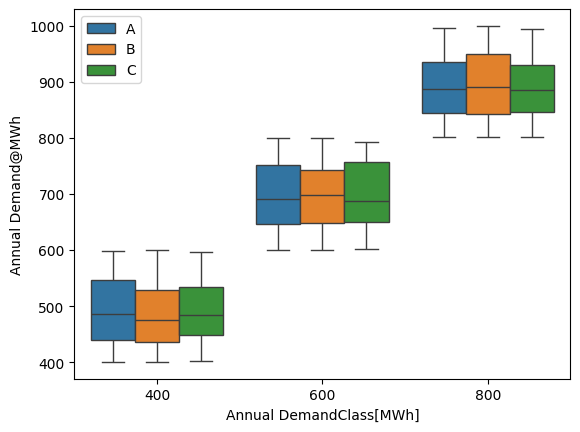

In [22]:
ax=sns.boxplot(data=DFSummary,x="DemandClass",y="Demand",hue="cluster",hue_order=hue_order_cluster)
#ax.set_ylim([0,7000])         
ax.set_ylabel("Annual Demand@MWh")  
ax.set_xlabel("Annual DemandClass[MWh]")  
handles, labels = ax.get_legend_handles_labels()  # 凡例のハンドルとラベルを取得
#new_handles = [handle for handle, label in zip(handles, labels) if label != "C"]
#new_labels = [label for label in labels if label != "C"]
#ax.legend(handles=new_handles, labels=new_labels)
ax.legend()

plt.savefig("IMG/Demand_box.png")
plt.show()

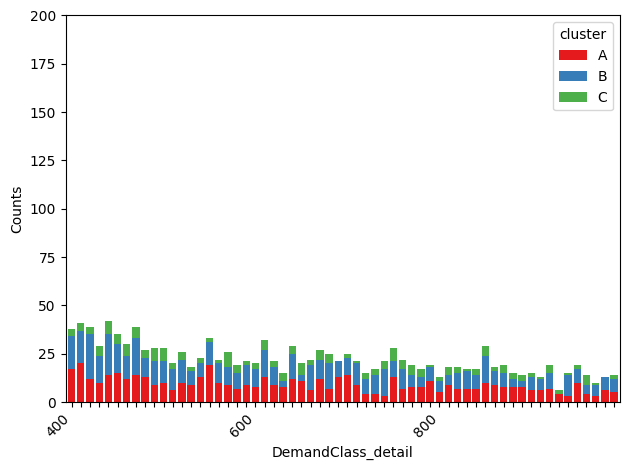

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette("Set1") 

df = DFSummary[DFSummary["Scinario"] == 1]

# グループ化してカウント、積み上げ順を逆に
grouped = df.groupby(["DemandClass_detail", "cluster"]).count()["name"].unstack()
colors = [cluster_color_map[c] for c in grouped.columns]


# 棒グラフ描画
ax = grouped.plot.bar(stacked=True,width=0.8,color=colors)

# Y軸の設定
ax.set_ylim(0, 200)
ax.set_ylabel("Counts")
ax.set_xlabel("DemandClass_detail")

# X軸ラベルを200ごとに間引く
xticks = grouped.index.tolist()
xtick_labels = [str(x) if int(x) % 200 == 0 else "" for x in xticks]
ax.set_xticks(range(len(xticks)))
ax.set_xticklabels(xtick_labels, rotation=45, ha='right')

plt.tight_layout()
plt.savefig("IMG/DemandClass_cluster_counts.png", bbox_inches='tight')


In [24]:
xtick = [f"{x}-{x+200}" for x in range(400, 1000, 200)]
#xtick = ["~"+str(x) for x in range(500,1100,200)]

In [25]:
xtick

['400-600', '600-800', '800-1000']

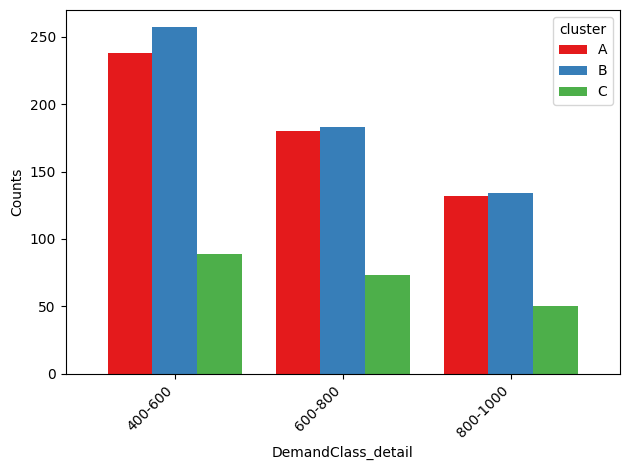

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette("Set1") 

df = DFSummary[DFSummary["Scinario"] == 1]

# グループ化してカウント、積み上げ順を逆に
grouped = df.groupby(["DemandClass", "cluster"]).count()["name"].unstack()

# 棒グラフ描画
colors = [cluster_color_map[c] for c in grouped.columns]

ax = grouped.plot.bar(
    width=0.8,
    color=colors
)

#ax = grouped.plot.bar(width=0.8)

# Y軸の設定
#ax.set_ylim(0, 200)
ax.set_ylabel("Counts")
ax.set_xlabel("DemandClass_detail")



# X軸ラベルを200ごとに間引く
xticks = grouped.index.tolist()
xtick_labels = [str(x) if int(x) % 200 == 0 else "" for x in xticks]
#ax.set_xticks(range(len(xticks)))
ax.set_xticklabels(xtick, rotation=45, ha='right')

plt.tight_layout()
plt.savefig("IMG/DemandClass_cluster_max.png", bbox_inches='tight')


In [27]:
#Demand A
DFSummary[DFSummary["name"]=="B11005006"]

,name,Num_EV,TripEnergy,Demand,RES,SolarCapacity,BESS_BatteryCapacity,BuyPowerEnergy,ContractPower,Cost,...,ContractCost,Is_opt_solarcapacity,Is_opt_BESS,TripType,ChargeType,ControlRatio,Scinario,DemandClass,DemandClass_detail,cluster
6120,B11005006,0,0.000000,786.205,0.000000,0.000000,0,786205.000000,268.000000,1799.502400,...,541.574400,False,False,Office,V2B,0,1,600,780,C
6121,B11005006,0,0.000000,786.205,322057.460178,231.746032,0,478921.460514,229.460317,1229.967746,...,463.693410,True,False,Office,V2B,0,2,600,780,C
6122,B11005006,15,27364.298197,786.205,322057.460178,231.746032,0,505952.164791,230.087594,1274.484473,...,464.961009,False,False,Office,V2B,0,3,600,780,C
6123,B11005006,15,27364.298197,786.205,322057.460178,231.746032,0,505952.164791,230.087594,1274.484473,...,464.961009,False,False,Office,V2B,0,4,600,780,C
6124,B11005006,15,27364.298197,786.205,322057.460178,231.746032,0,493526.607647,181.460317,1156.337582,...,366.695010,False,False,Office,V2B,1,5,600,780,C
6125,B11005006,15,27364.298197,786.205,425206.719840,305.970152,0,406307.624715,175.522388,1004.787841,...,354.695641,True,False,Office,V2B,1,6,600,780,C


In [28]:
#Demand B
DFSummary[DFSummary["name"]=="B11002460"]

,name,Num_EV,TripEnergy,Demand,RES,SolarCapacity,BESS_BatteryCapacity,BuyPowerEnergy,ContractPower,Cost,...,ContractCost,Is_opt_solarcapacity,Is_opt_BESS,TripType,ChargeType,ControlRatio,Scinario,DemandClass,DemandClass_detail,cluster
2952,B11002460,0,0.000000,620.528,0.000000,0.000000,0,620528.000000,254.000000,1506.128000,...,513.283200,False,False,Office,V2B,0,1,600,620,B
2953,B11002460,0,0.000000,620.528,86484.905659,62.264151,0,549431.679249,247.150943,1378.533313,...,499.442626,True,False,Office,V2B,0,2,600,620,B
2954,B11002460,15,27281.139291,620.528,86484.905659,62.264151,0,576754.683640,247.957441,1423.879891,...,501.072398,False,False,Office,V2B,0,3,600,620,B
2955,B11002460,15,27281.139291,620.528,86484.905659,62.264151,0,576754.683640,247.957441,1423.879891,...,501.072398,False,False,Office,V2B,0,4,600,620,B
2956,B11002460,15,27281.139291,620.528,86484.905659,62.264151,0,562003.780074,193.566038,1290.364297,...,391.158249,False,False,Office,V2B,1,5,600,620,B
2957,B11002460,15,27281.139291,620.528,266751.138431,192.045456,0,407318.490845,178.875000,1013.180185,...,361.470600,True,False,Office,V2B,1,6,600,620,B


In [29]:
dict_key = {}
dict_key["Cost"]={}

dict_key["EnergyCost"]={}
dict_key["ContractCost"]={}
dict_key["SolarCapacity"]={}
dict_key["Cost"]["unit"]="Cost Reduction [kJPY]"
dict_key["EnergyCost"]["unit"]="Energy Cost Reduction [kJPY]"
dict_key["ContractCost"]["unit"]="Basic Cost Reduction [kJPY]"
dict_key["SolarCapacity"]["unit"]="ΔSolar capacity[kW]"
dict_key["Cost"]["range"]=[0,600]
dict_key["EnergyCost"]["range"]=[0,2500]
dict_key["ContractCost"]["range"]=[0,300]
dict_key["SolarCapacity"]["range"]=[0,1000]

In [30]:
unique_name = DFSummary.loc[DFSummary["SolarCapacity"] >= 0, "name"].unique()
DFSummary = DFSummary[DFSummary["name"].isin(unique_name)]


In [31]:
DFSummary["Cost"]=DFSummary["Cost"]*10
DFSummary["EnergyCost"]=DFSummary["EnergyCost"]*10
DFSummary["ContractCost"]=DFSummary["ContractCost"]*10

Cost
1 {'NumEV': 0, 'PVw/EV': False, 'NumICE': 15, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 1}
2 {'NumEV': 0, 'PVw/EV': True, 'NumICE': 15, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 1}


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\4265200393.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtick)


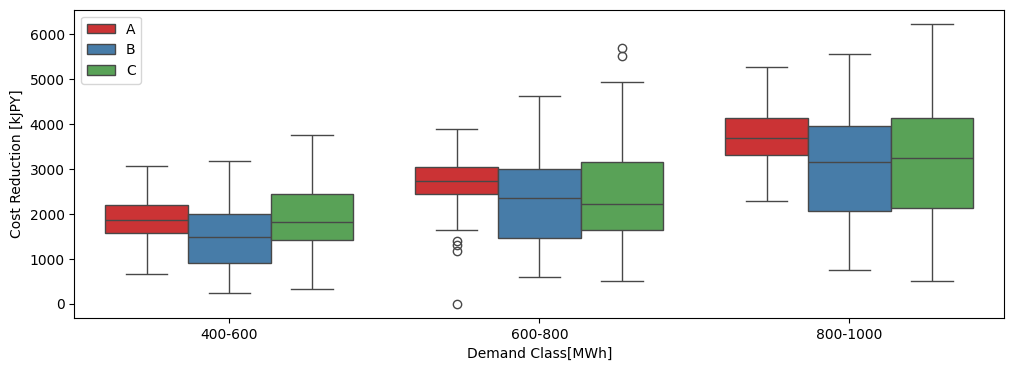

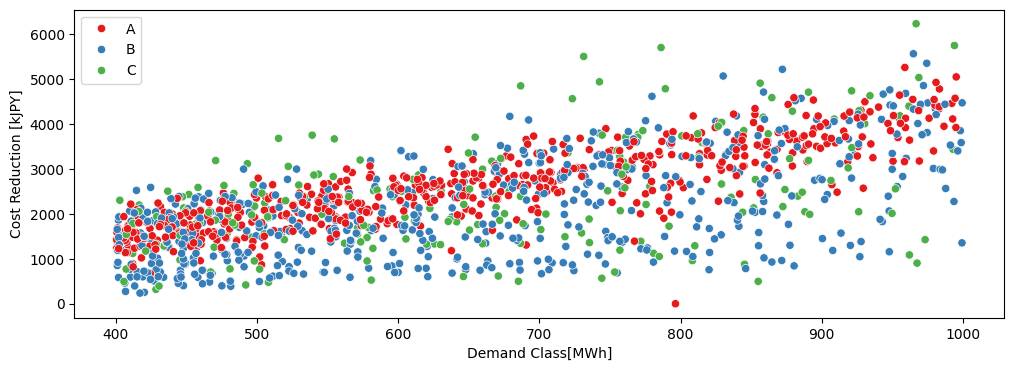

EnergyCost
1 {'NumEV': 0, 'PVw/EV': False, 'NumICE': 15, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 1}
2 {'NumEV': 0, 'PVw/EV': True, 'NumICE': 15, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 1}


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\4265200393.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtick)


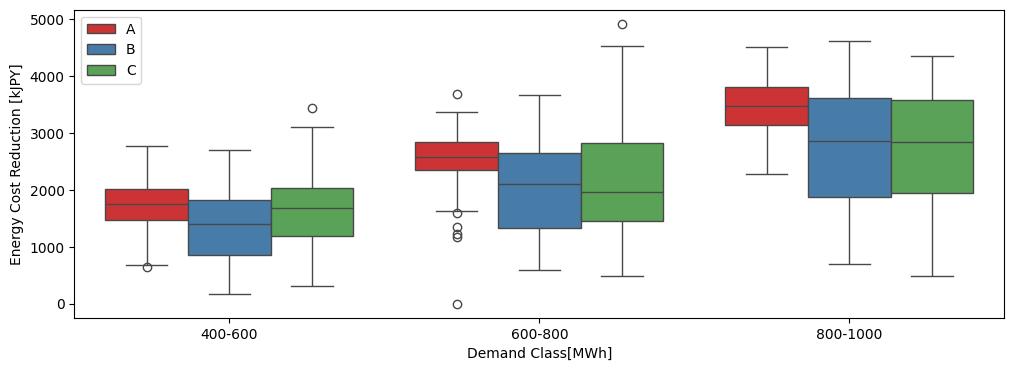

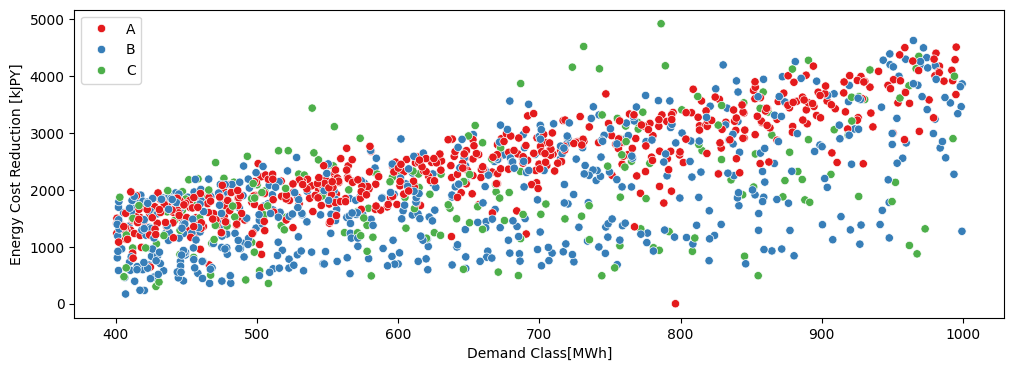

ContractCost
1 {'NumEV': 0, 'PVw/EV': False, 'NumICE': 15, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 1}
2 {'NumEV': 0, 'PVw/EV': True, 'NumICE': 15, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 1}


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\4265200393.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtick)


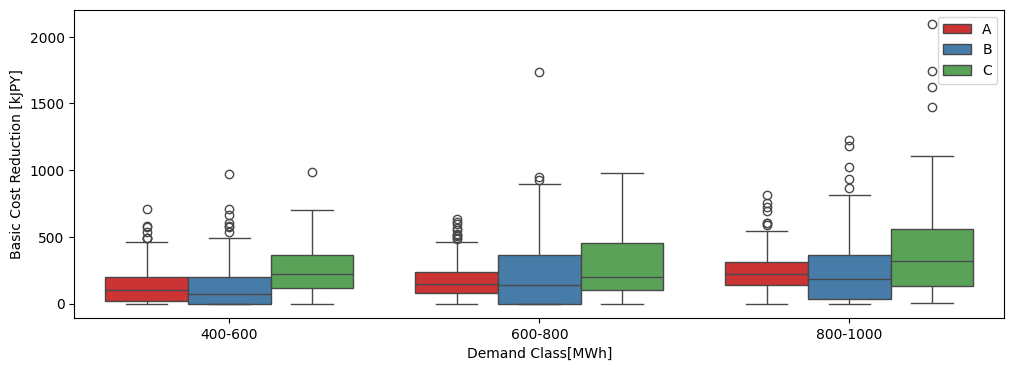

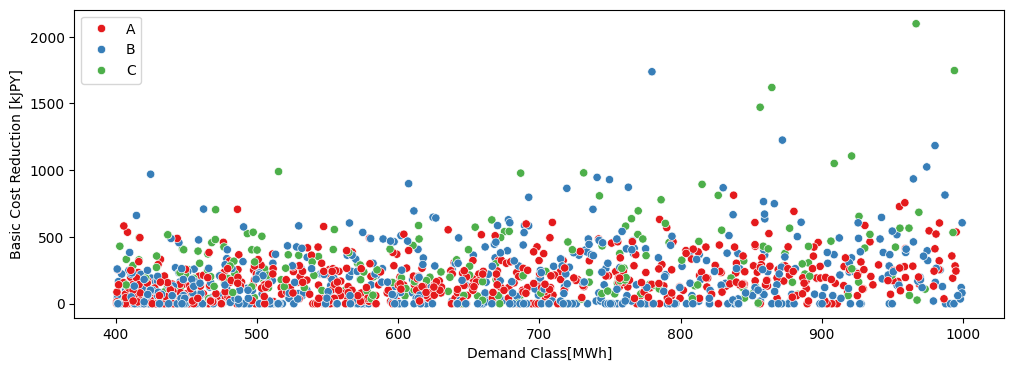

SolarCapacity
1 {'NumEV': 0, 'PVw/EV': False, 'NumICE': 15, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 1}
2 {'NumEV': 0, 'PVw/EV': True, 'NumICE': 15, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 1}


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\4265200393.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtick)


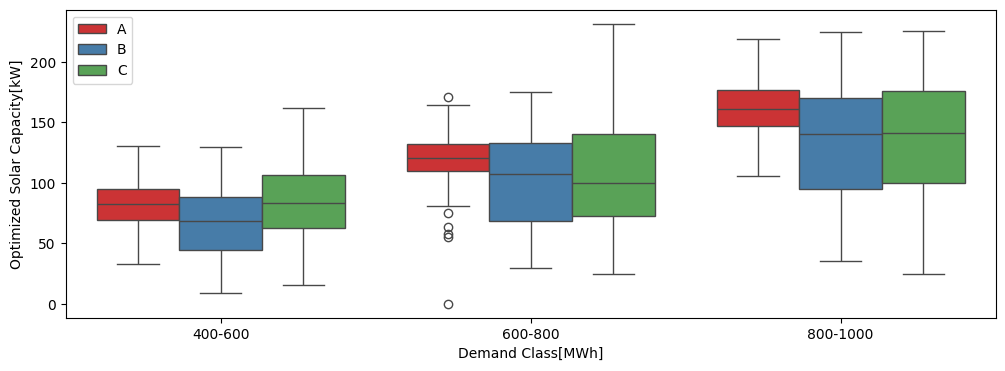

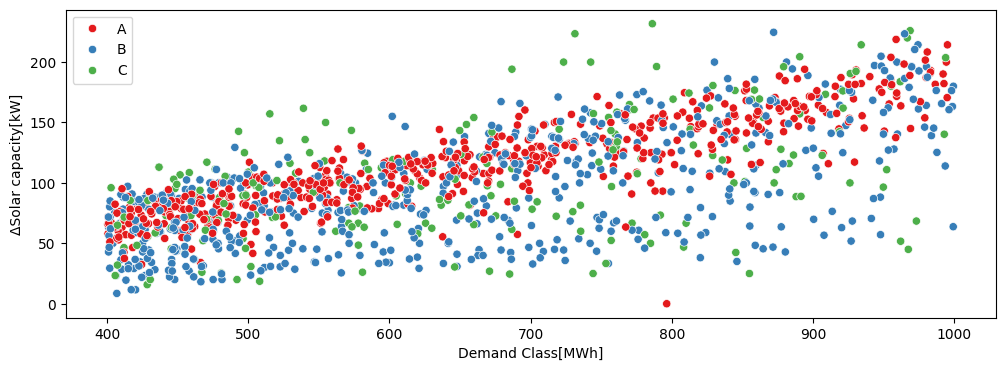

Cost
2 {'NumEV': 0, 'PVw/EV': True, 'NumICE': 15, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 1}
3 {'NumEV': 15, 'PVw/EV': False, 'NumICE': 0, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 2}


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\4265200393.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtick)


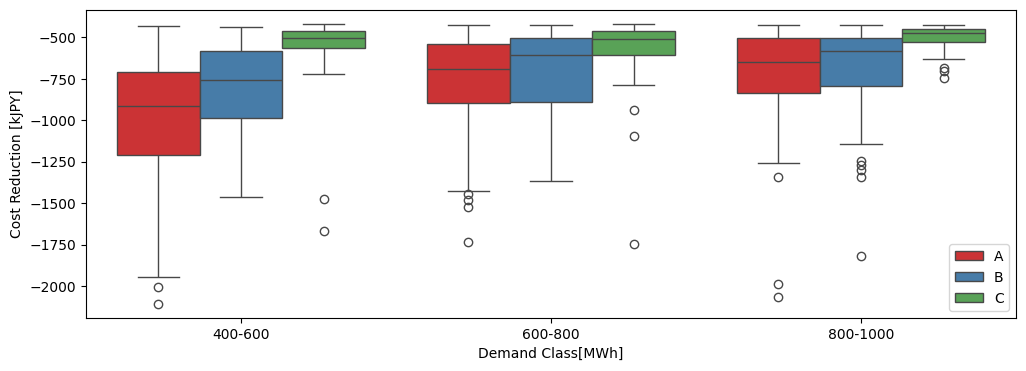

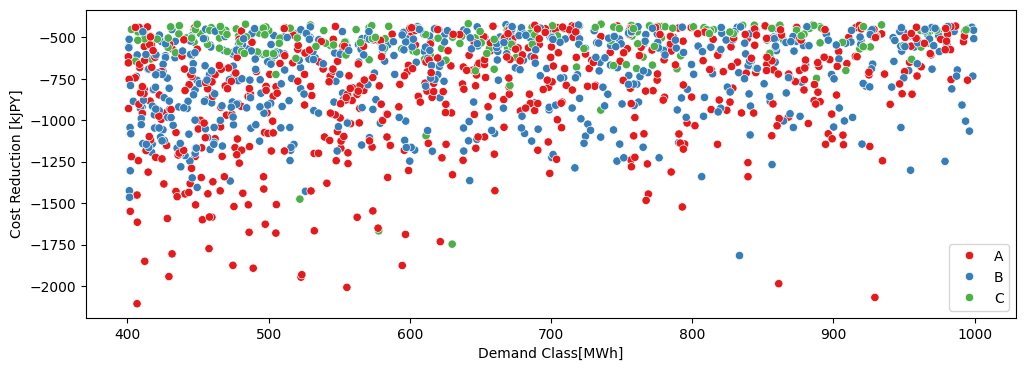

EnergyCost
2 {'NumEV': 0, 'PVw/EV': True, 'NumICE': 15, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 1}
3 {'NumEV': 15, 'PVw/EV': False, 'NumICE': 0, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 2}


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\4265200393.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtick)


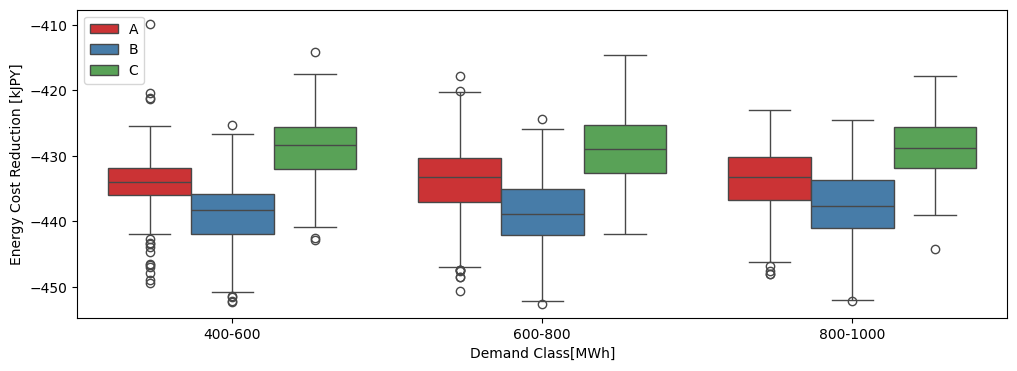

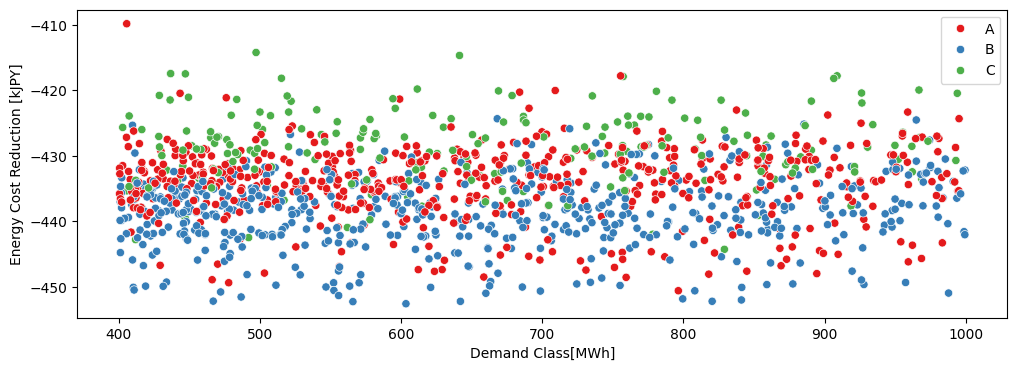

ContractCost
2 {'NumEV': 0, 'PVw/EV': True, 'NumICE': 15, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 1}
3 {'NumEV': 15, 'PVw/EV': False, 'NumICE': 0, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 2}


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\4265200393.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtick)


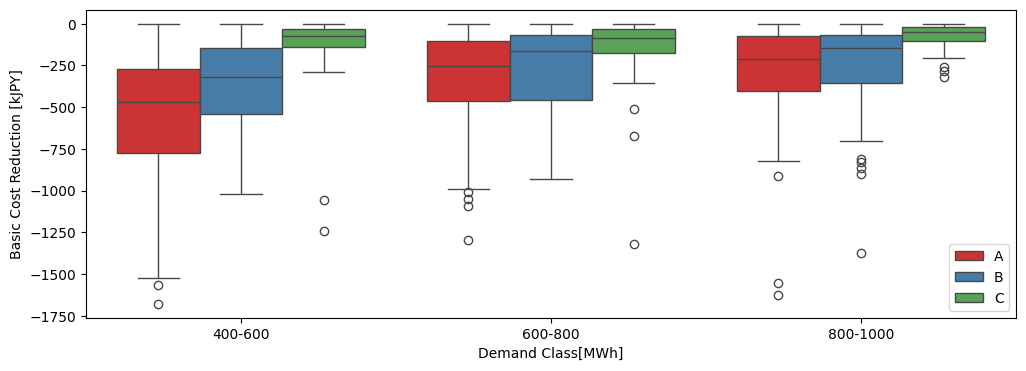

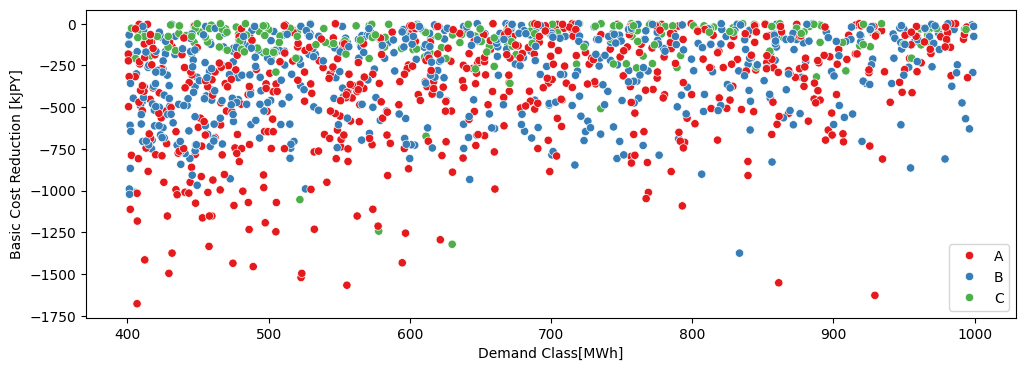

SolarCapacity
2 {'NumEV': 0, 'PVw/EV': True, 'NumICE': 15, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 1}
3 {'NumEV': 15, 'PVw/EV': False, 'NumICE': 0, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 2}


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\4265200393.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtick)


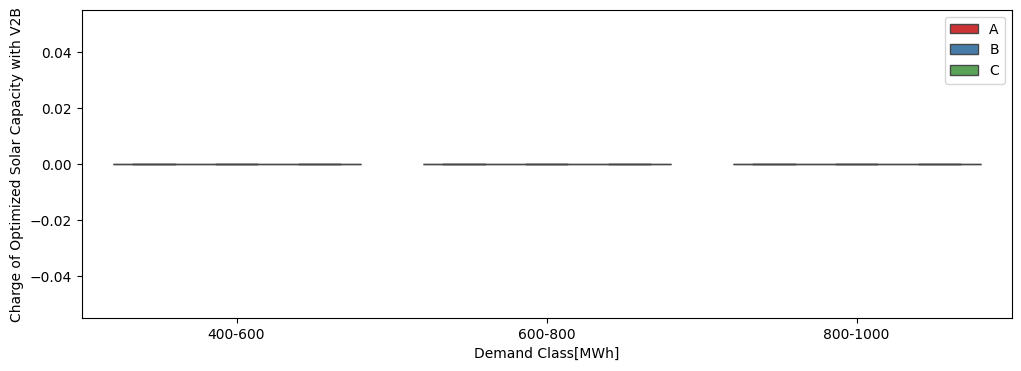

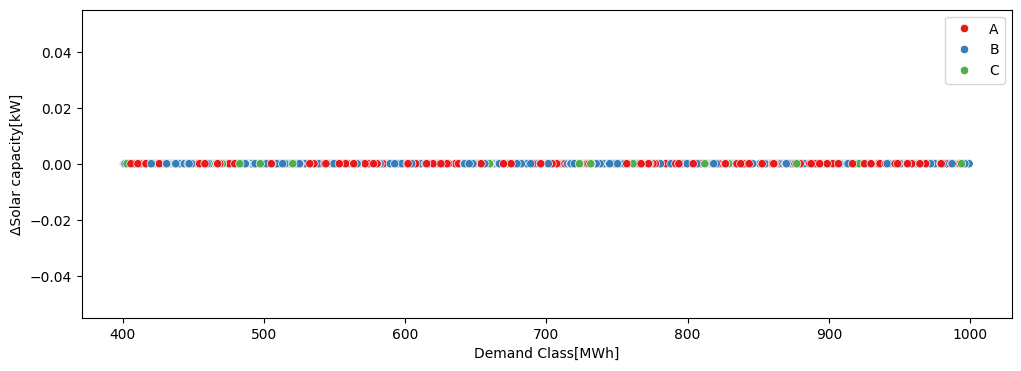

Cost
3 {'NumEV': 15, 'PVw/EV': False, 'NumICE': 0, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 2}
4 {'NumEV': 15, 'PVw/EV': True, 'NumICE': 0, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 3}


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\4265200393.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtick)


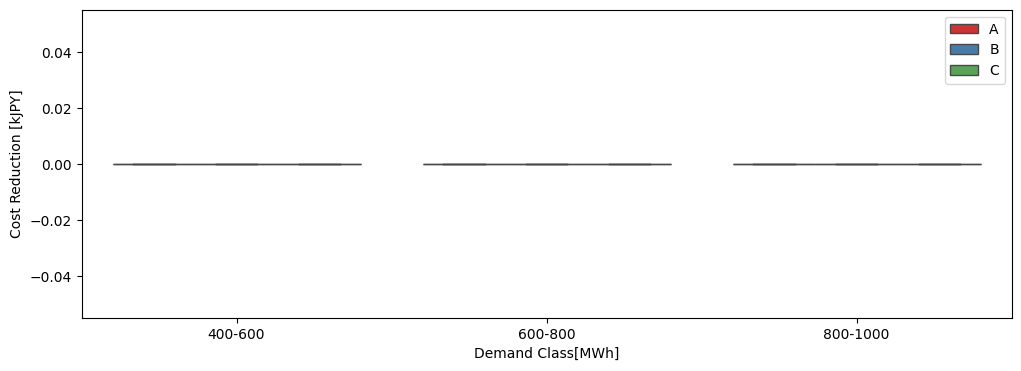

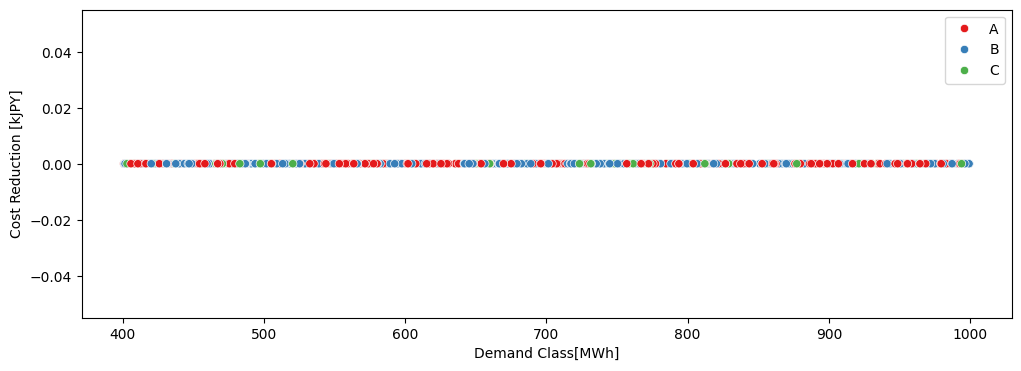

EnergyCost
3 {'NumEV': 15, 'PVw/EV': False, 'NumICE': 0, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 2}
4 {'NumEV': 15, 'PVw/EV': True, 'NumICE': 0, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 3}


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\4265200393.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtick)


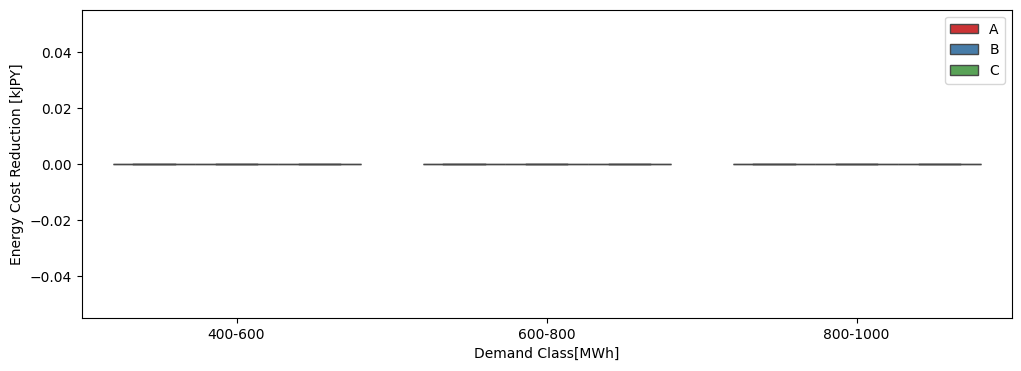

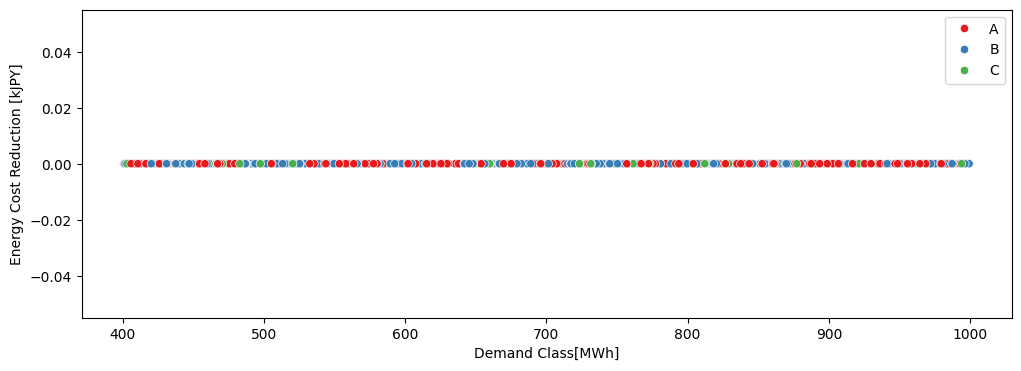

ContractCost
3 {'NumEV': 15, 'PVw/EV': False, 'NumICE': 0, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 2}
4 {'NumEV': 15, 'PVw/EV': True, 'NumICE': 0, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 3}


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\4265200393.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtick)


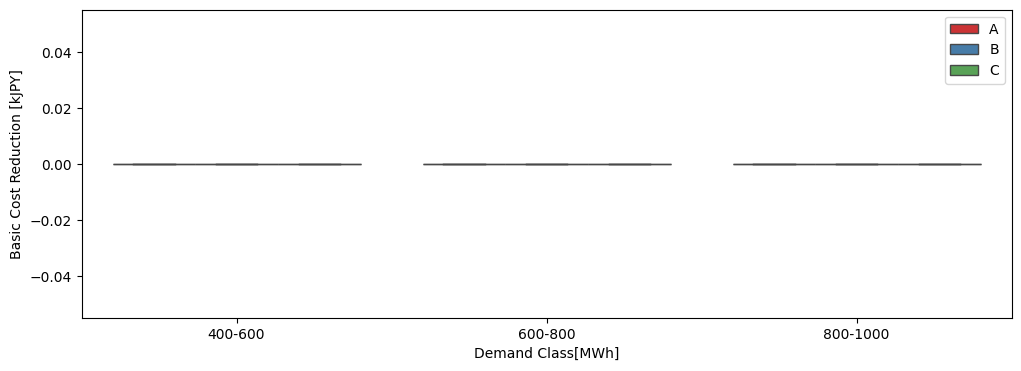

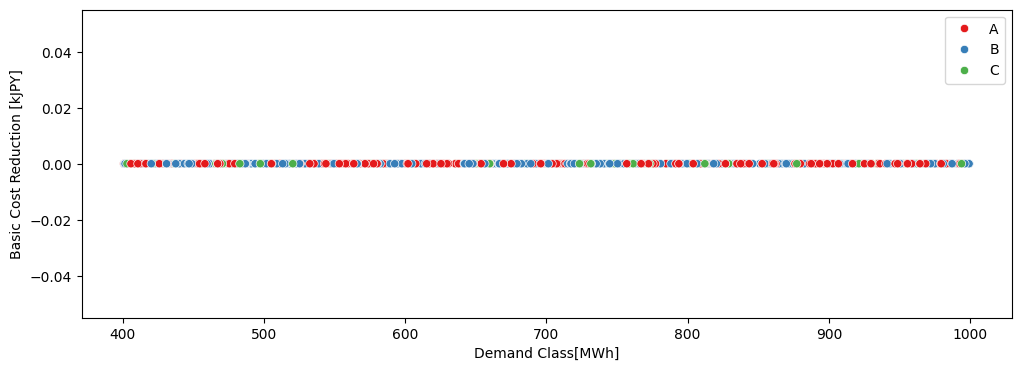

SolarCapacity
3 {'NumEV': 15, 'PVw/EV': False, 'NumICE': 0, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 2}
4 {'NumEV': 15, 'PVw/EV': True, 'NumICE': 0, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 3}


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\4265200393.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtick)


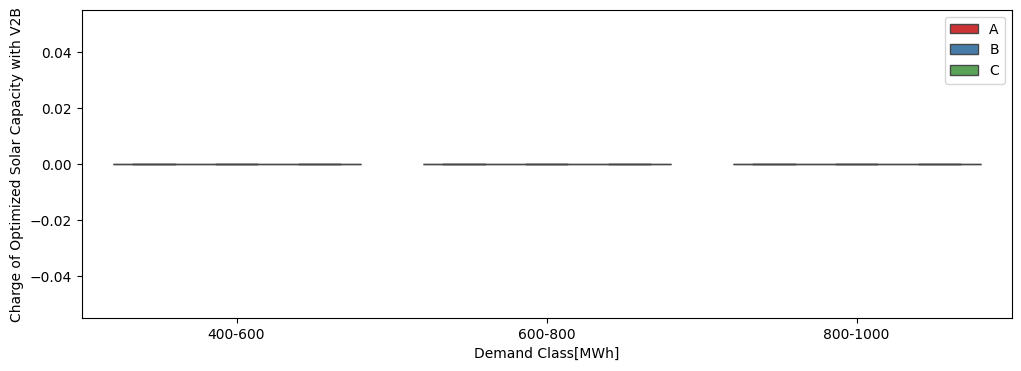

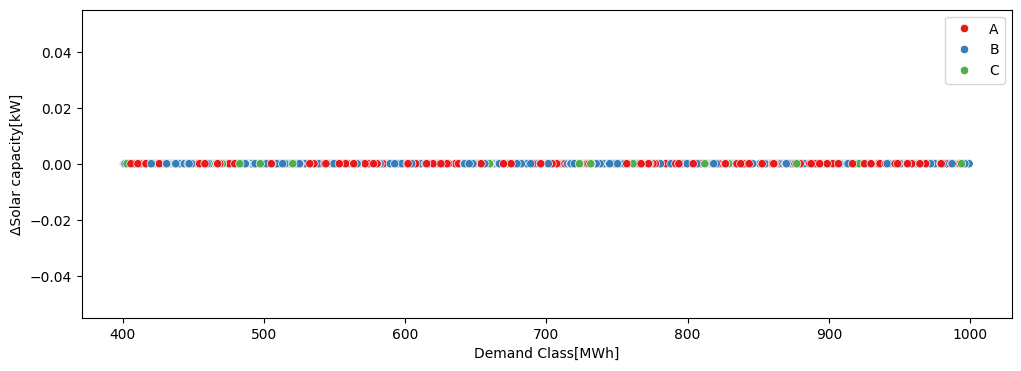

Cost
4 {'NumEV': 15, 'PVw/EV': True, 'NumICE': 0, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 3}
5 {'NumEV': 15, 'PVw/EV': False, 'NumICE': 0, 'ControlRatio': 1, 'Opt_BESS': False, 'PVCapacity_Scinario': 4}


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\4265200393.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtick)


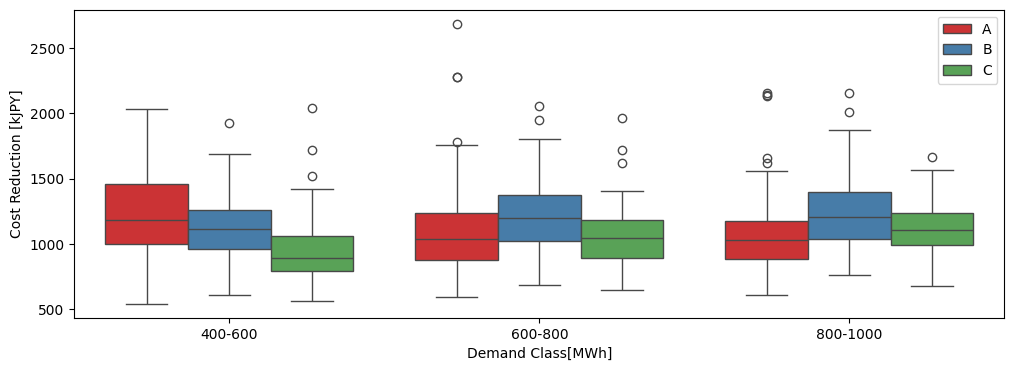

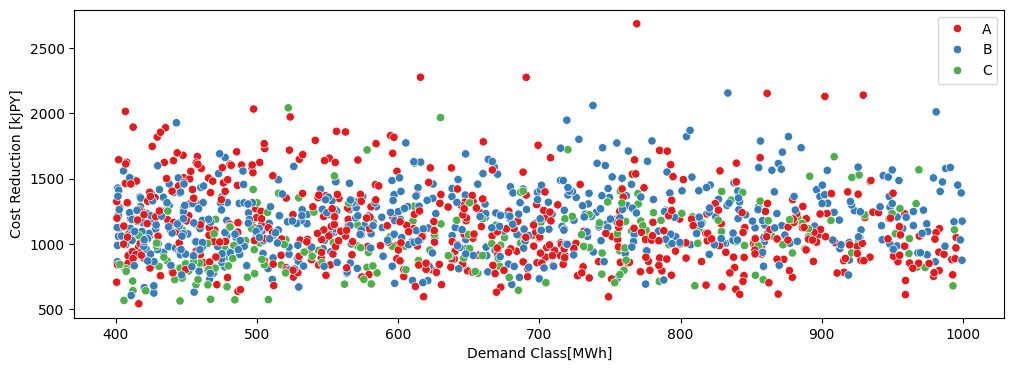

EnergyCost
4 {'NumEV': 15, 'PVw/EV': True, 'NumICE': 0, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 3}
5 {'NumEV': 15, 'PVw/EV': False, 'NumICE': 0, 'ControlRatio': 1, 'Opt_BESS': False, 'PVCapacity_Scinario': 4}


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\4265200393.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtick)


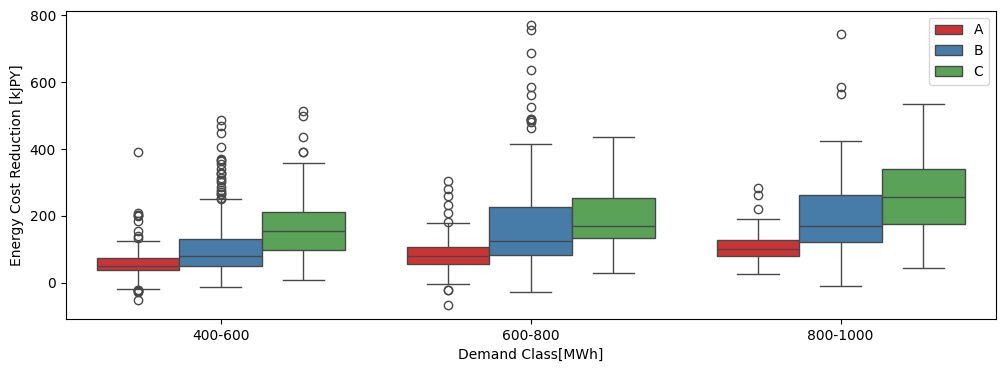

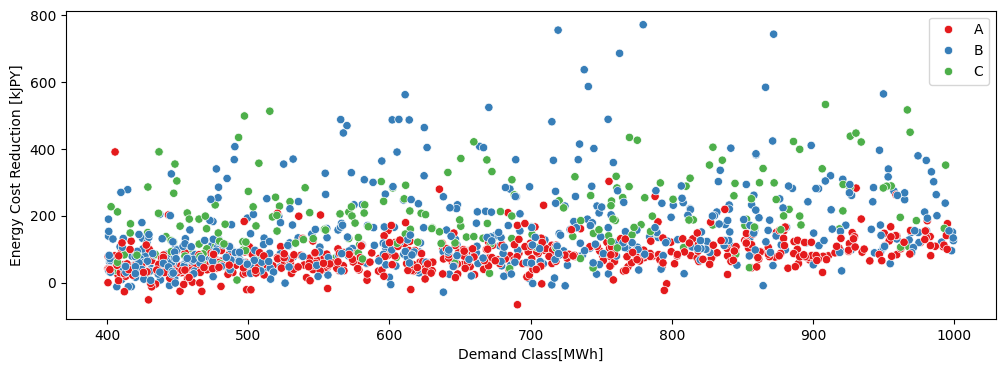

ContractCost
4 {'NumEV': 15, 'PVw/EV': True, 'NumICE': 0, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 3}
5 {'NumEV': 15, 'PVw/EV': False, 'NumICE': 0, 'ControlRatio': 1, 'Opt_BESS': False, 'PVCapacity_Scinario': 4}


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\4265200393.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtick)


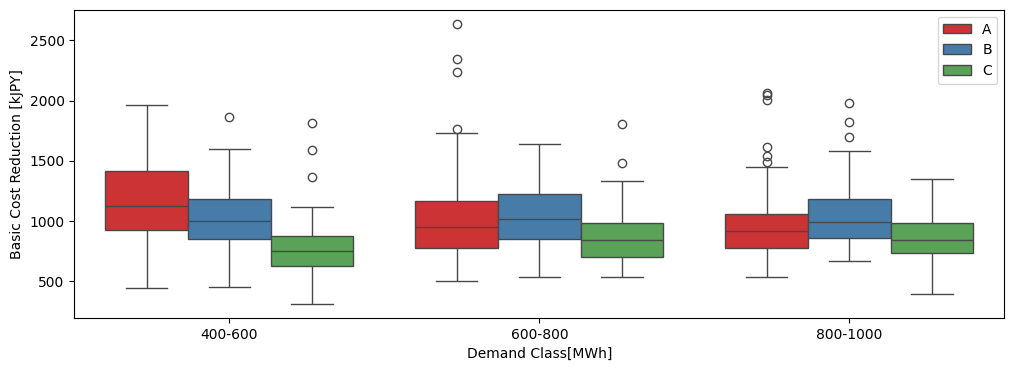

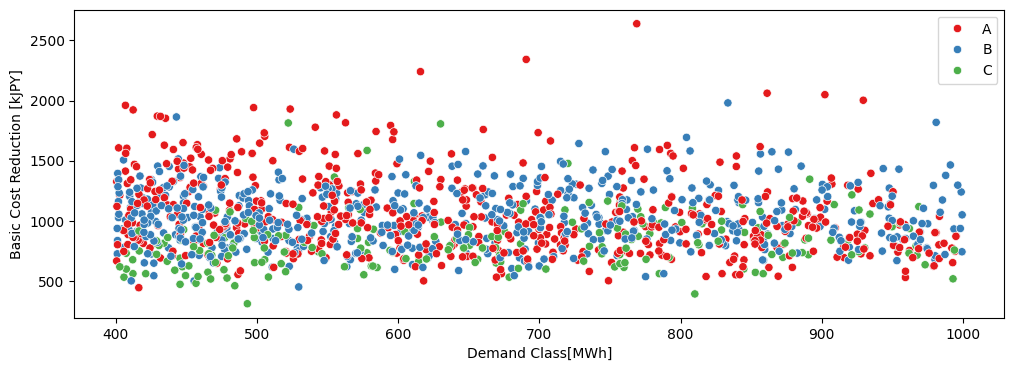

SolarCapacity
4 {'NumEV': 15, 'PVw/EV': True, 'NumICE': 0, 'ControlRatio': 0, 'Opt_BESS': False, 'PVCapacity_Scinario': 3}
5 {'NumEV': 15, 'PVw/EV': False, 'NumICE': 0, 'ControlRatio': 1, 'Opt_BESS': False, 'PVCapacity_Scinario': 4}


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\4265200393.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtick)


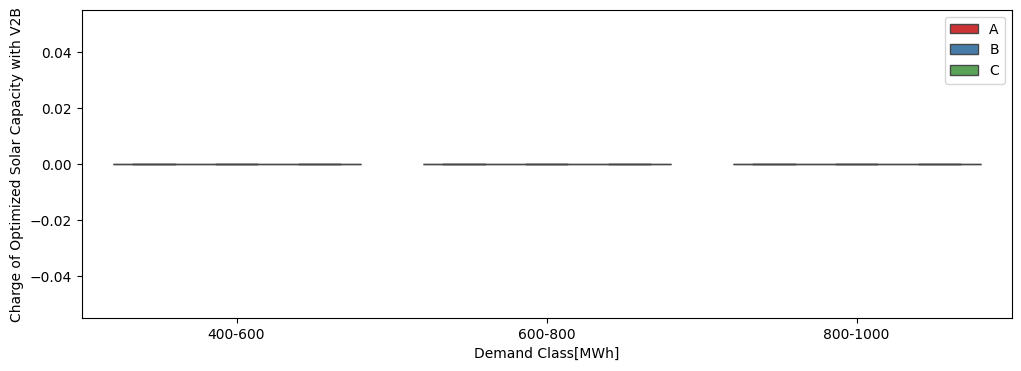

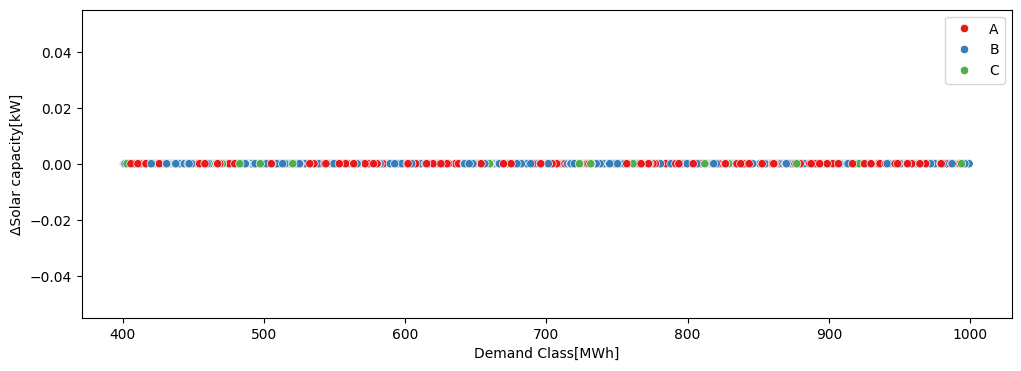

Cost
5 {'NumEV': 15, 'PVw/EV': False, 'NumICE': 0, 'ControlRatio': 1, 'Opt_BESS': False, 'PVCapacity_Scinario': 4}
6 {'NumEV': 15, 'PVw/EV': True, 'NumICE': 0, 'ControlRatio': 1, 'Opt_BESS': False, 'PVCapacity_Scinario': 5}


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\4265200393.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtick)


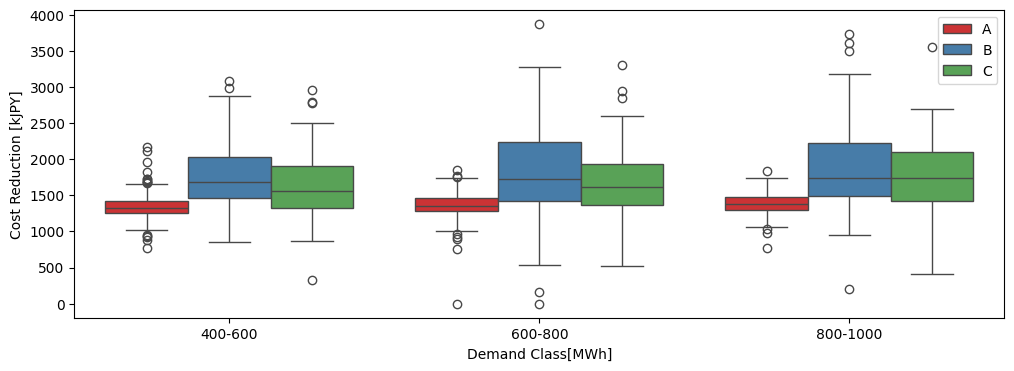

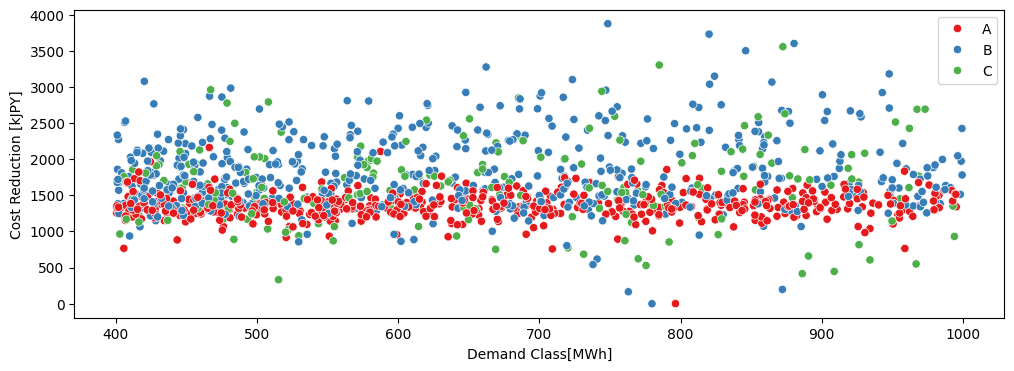

EnergyCost
5 {'NumEV': 15, 'PVw/EV': False, 'NumICE': 0, 'ControlRatio': 1, 'Opt_BESS': False, 'PVCapacity_Scinario': 4}
6 {'NumEV': 15, 'PVw/EV': True, 'NumICE': 0, 'ControlRatio': 1, 'Opt_BESS': False, 'PVCapacity_Scinario': 5}


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\4265200393.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtick)


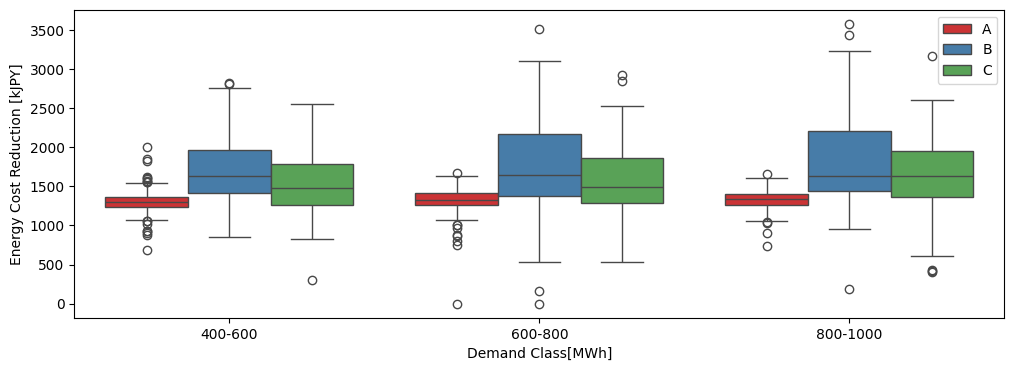

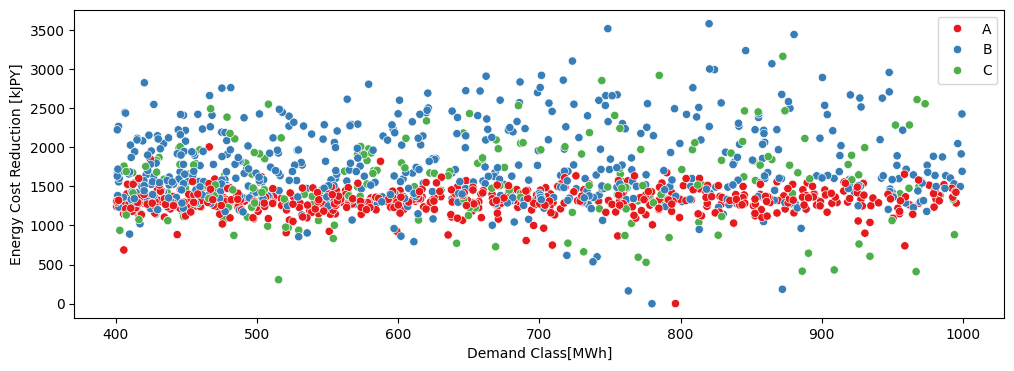

ContractCost
5 {'NumEV': 15, 'PVw/EV': False, 'NumICE': 0, 'ControlRatio': 1, 'Opt_BESS': False, 'PVCapacity_Scinario': 4}
6 {'NumEV': 15, 'PVw/EV': True, 'NumICE': 0, 'ControlRatio': 1, 'Opt_BESS': False, 'PVCapacity_Scinario': 5}


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\4265200393.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtick)


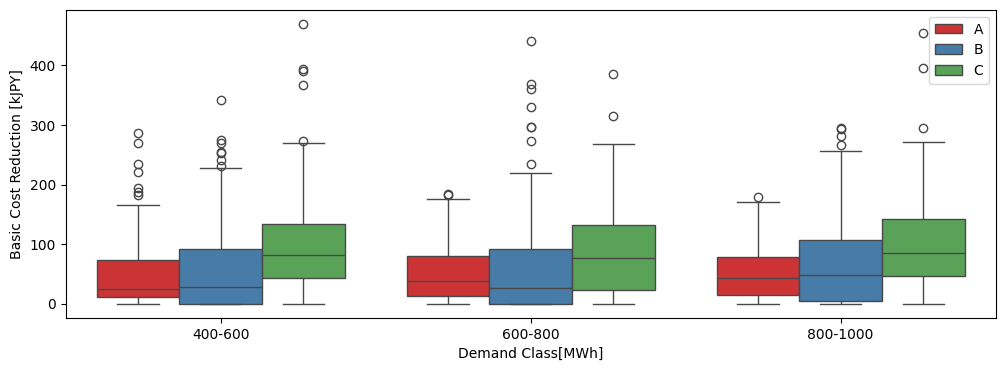

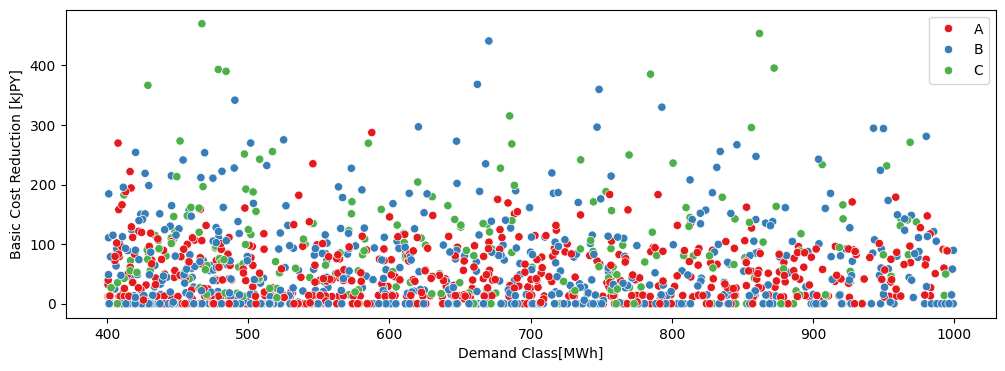

SolarCapacity
5 {'NumEV': 15, 'PVw/EV': False, 'NumICE': 0, 'ControlRatio': 1, 'Opt_BESS': False, 'PVCapacity_Scinario': 4}
6 {'NumEV': 15, 'PVw/EV': True, 'NumICE': 0, 'ControlRatio': 1, 'Opt_BESS': False, 'PVCapacity_Scinario': 5}


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\4265200393.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtick)


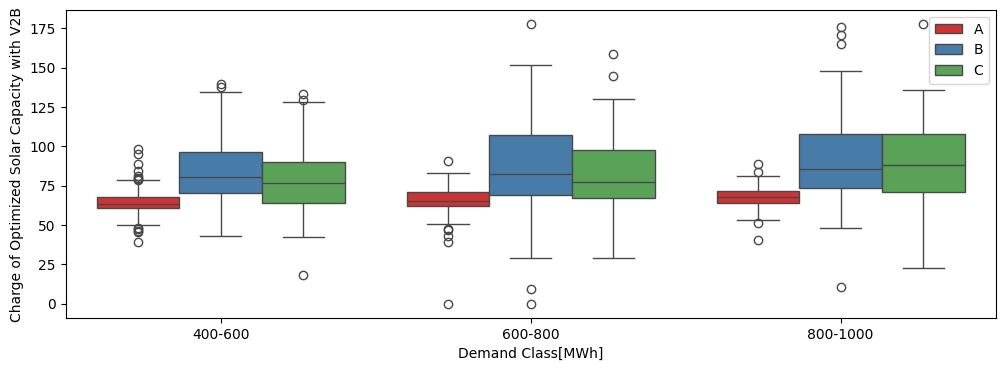

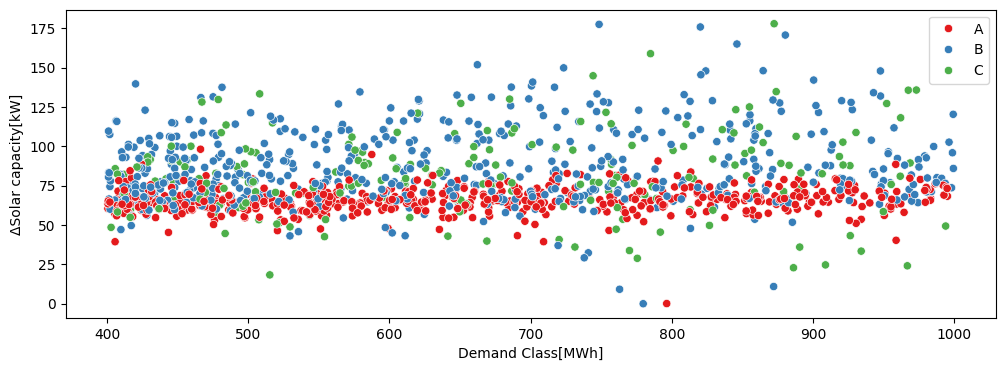

In [32]:
os.makedirs("IMG",exist_ok=True)
for reference in dictScinario.keys():
    for scinario in dictScinario.keys():
        if (scinario - reference)>1:continue
        if (scinario<=reference):continue
        #if not (reference==4)&(scinario==5):continue
        for key in ["Cost","EnergyCost","ContractCost","SolarCapacity"]:
            #if not (key=="ContractCost"):continue
            print(key)
            print(reference,dictScinario[reference])
            print(scinario,dictScinario[scinario])
            dfref=DFSummary[DFSummary["Scinario"]==reference]
            dfscio=DFSummary[DFSummary["Scinario"]==scinario]
            df = dfref[["name",key]]
            df = df.merge(dfscio, on="name", suffixes=("_ref", "_scio"))
            if key=="SolarCapacity":
                df.loc[:,key] = df.loc[:,key+"_scio"]-df.loc[:,key+"_ref"]
            else:    
                df.loc[:,key] = df.loc[:,key+"_ref"]-df.loc[:,key+"_scio"]
            
            plt.figure(figsize=(12, 4))
            ax1 = sns.boxplot(data=df,x="DemandClass",y=key,hue="cluster",palette="Set1",hue_order=hue_order_cluster)
            
            handles, labels = ax1.get_legend_handles_labels()  
            # new_handles = [handle for handle, label in zip(handles, labels) if label != "D"]
            # new_labels = [label for label in labels if label != "D"]
            # ax1.legend(handles=new_handles, labels=new_labels,loc="upper left", bbox_to_anchor=(1, 1),title="cluster")
            ax1.legend()
            
            if key=="SolarCapacity":
                if scinario == 2:
                    ax1.set_ylabel("Optimized Solar Capacity[kW]")  
                else:
                    ax1.set_ylabel("Charge of Optimized Solar Capacity with V2B")  
            else:
                ax1.set_ylabel(dict_key[key]["unit"])  
            ax1.set_xlabel("Demand Class[MWh]")  
            ax1.set_xticklabels(xtick)
            #ax1.legend(loc="upper left", bbox_to_anchor=(1, 1),title="cluster")
            plt.savefig("IMG/"+str(reference)+"-"+str(scinario)+str(key)+"_box.png", bbox_inches='tight')
            plt.show()
            
            plt.figure(figsize=(12, 4))
            ax2=sns.scatterplot(data=df,x="Demand",y=key,hue="cluster",hue_order=hue_order_cluster)

            handles, labels = ax2.get_legend_handles_labels()  
            # new_handles = [handle for handle, label in zip(handles, labels) if label != "D"]
            # new_labels = [label for label in labels if label != "D"]
            # ax2.legend(handles=new_handles, labels=new_labels)
            ax2.legend()
            
            ax2.set_ylabel(dict_key[key]["unit"])  
            ax2.set_xlabel("Demand Class[MWh]")  
            plt.savefig("IMG/"+str(reference)+"-"+str(scinario)+str(key)+"_scatter.png", bbox_inches='tight')
            plt.show()
      
            

In [33]:
DFSummary["Cost"]=DFSummary["Cost"]/10
DFSummary["EnergyCost"]=DFSummary["EnergyCost"]/10
DFSummary["ContractCost"]=DFSummary["ContractCost"]/10

In [34]:
#Energy assesment indicator
def SCR(Demand,RES,EV_Charge,BESS_Charge):
    Edu = sum(np.minimum(Demand, RES))
    Ech = sum(np.minimum(np.maximum(RES-Demand,0),np.maximum(EV_Charge,0)))
    Ebch = sum(np.minimum(np.maximum(RES-Demand-EV_Charge,0),np.maximum(BESS_Charge,0)))
    if sum(RES)==0:return(0,Ech)
    SCR = (Edu+Ech+Ebch)/sum(RES)
    return (SCR,Ech)
def SSR(Demand,RES,EV_Charge,BESS_Charge):
    Edu = sum(np.minimum(Demand, RES))
    Ech = sum(np.minimum(np.maximum(RES-Demand,0),np.maximum(EV_Charge,0)))
    Ebch = sum(np.minimum(np.maximum(RES-Demand-EV_Charge,0),np.maximum(BESS_Charge,0)))
    Eload = sum(Demand+EV_Charge+BESS_Charge)
    SSR = (Edu+Ech+Ebch)/Eload
    return(SSR)

In [35]:
lifetime_Solarpanel = 20 #year
Price_ini_Solarpanel = 25.5 #10kyen/kW
Price_om_Solarpanel = 0.5 #10kyen/kW/year


Price_init_V2H = 33 #10kyen
Price_om_V2H = 0.6 #10kyen
lifetime_V2H = 10 #year

Price_init_NC = 15 #10kyen
Price_om_NC = 0.1 #10kyen
lifetime_NC = 10 #year

Price_init_BESS = 18.7 #10kyen
Price_om_BESS = 0.47 #10kyen
lifetime_BESS = 10 #year

#Price_init_ICE = 300 #10kyen
#Price_om_ICE = 14.4 #10kyen
Price_init_ICE = 0 #10kyen
Price_om_ICE = 0 #10kyen
lifetime_ICE = 15 #year

# Price_init_EV = 500 #10kyen
# Price_om_EV = 14.4 #10kyen
Price_init_EV = 0 #10kyen
Price_om_EV = 0 #10kyen
lifetime_EV = 15 #year

Price_ContaractPower =  1684 #yen/kW/year
Price_ComsumptionEnergy = 16#yen/kWh

AnnualGeneration=1388.15#kWh
        


In [36]:
#Economic assessment indicator
def LCOE(Demand,RES,EV_Charge,BESS_Charge,dict_price):
    if Scinario==0:return 0,0,0,0
    Cini = (dict_price["PVini"]+dict_price["V2Hini"]+dict_price["NCini"]+dict_price["BESSini"])*10**4
    Canu = (dict_price["PVom"]+dict_price["V2Hom"]+dict_price["NCom"]+dict_price["BESSom"])*10**4
    EV_Charge_pos = np.maximum(EV_Charge,0)
    EV_Charge_neg = np.minimum(EV_Charge,0)
    BESS_Charge_pos = np.maximum(BESS_Charge,0)
    BESS_Charge_neg = np.minimum(BESS_Charge,0)
    sumCanu=0
    n = 15
    Csal = 0
    Edu = sum(np.minimum(Demand, RES-EV_Charge_neg-BESS_Charge_neg))
    sumEdu = 0
    Ebc = sum(np.minimum(np.maximum(RES-Demand-EV_Charge_neg-BESS_Charge_neg,0),EV_Charge_pos))
    sumEbc = 0
    Ebbc = sum(np.minimum(np.maximum(RES-Demand-EV_Charge_neg-BESS_Charge_neg-EV_Charge,0),BESS_Charge_pos))
    sumEbbc = 0
    r=0.03
    for y in range(n):
        sumCanu += Canu/((1+r)**y)
        sumEdu += (Edu)/((1+r)**y)
        sumEbc += (Ebc)/((1+r)**y)
        sumEbbc += (Ebbc)/((1+r)**y)
    LCOE = (Cini+sumCanu+-Csal)/(sumEdu+sumEbc+Ebbc)
    return(LCOE,Edu,Ebc,Ebbc)

def opt_pvcapacity(Demand,ContractPower,NumEV,SCR):
    pvcost= (Price_ini_Solarpanel/lifetime_Solarpanel)+Price_om_Solarpanel
    v2hcost = (Price_init_V2H/lifetime_V2H)+Price_om_V2H
    costreduction_energy = AnnualGeneration*SCR*Price_ComsumptionEnergy/10000
    costreduction_power=(max(Demand)-ContractPower)*Price_ContaractPower*12/10000

    #print(pvcost,v2hcost,costreduction_energy,costreduction_power,NumEV,SCR,max(Demand),ContractPower)
    
    opt_capacity=(costreduction_power-v2hcost*NumEV)/(pvcost-costreduction_energy)
    return(opt_capacity)

def PBP(Demand,RES,ContractCost,EnergyCost,dict_price,refNumICE,NumICE,Scinario):
    
    Cini = dict_price["PVini"]* dict_price["Systemyear"]/dict_price["PVyear"]
    Cini += dict_price["V2Hini"]* dict_price["Systemyear"]/dict_price["V2Hyear"]
    Cini += dict_price["NCini"]* dict_price["Systemyear"]/dict_price["NCyear"]
    Cini += dict_price["BESSini"]* dict_price["Systemyear"]/dict_price["BESSyear"]

    Canu = (dict_price["PVom"]+dict_price["V2Hom"]+dict_price["NCom"]+dict_price["BESSom"])
    sumCanu=0
    Costref = (sum(Demand)*dict_price["Price_ComsumptionEnergy"]+max(Demand)*dict_price["Price_ContaractPower"]*12)/(10**4)+trvl_ICE(refNumICE,10000)
    Costopt =ContractCost+EnergyCost+trvl_ICE(NumICE,10000)
    Rdu = Costref-Costopt
    #if (Scinario==1)|(Scinario==3)|(Scinario==4):return (0,Cini,Canu,Rdu)
    if (Scinario==1):return (0,Cini,Canu,Rdu)
    
    sumRdu = 0
    r=0.03
    n = 15
    # for y in range(n):
    #     sumRdu  += Rdu/((1+r)**y)
    #     sumCanu += Canu/((1+r)**y)
    # PBP = (Cini+sumCanu)/(sumRdu/n)
    PBP = Cini/(Rdu - Canu)
    if PBP.item() < 0:
        PBP = None

    #print("Scinario",Scinario,"Cini",Cini,"Canu",Canu,"Rdu",Rdu,"PBP",PBP)
    return(PBP,Cini,Canu,Rdu)
def trvl_ICE(Num,AnnualTripDistance):
    Cost_Gasoline = 175#JPY
    Fuel_Efficiency = 22 #km/L
    Cost = Cost_Gasoline*AnnualTripDistance/Fuel_Efficiency/(10**4)*Num
    return(Cost)

In [37]:
#Environmental indicator
class LCA():
    def __init__(self):
        self.DF_LCIA = pd.read_excel("LCA/idea.xlsb",engine="pyxlsb",sheet_name=3,header=[0,1,2,3],index_col=0)
    def LCIA(self,code):
        name = self.DF_LCIA.loc[code].values[0]
        GHG = self.DF_LCIA.loc[code]["LIME2"]["特性化結果"]["気候変動"].values[0]
        unit = self.DF_LCIA.loc[code]["LIME2"]["特性化結果"]["気候変動"].index[0]
        return name,GHG,unit
    def prod_ICE(self,NumICE):
        code = "311100000mJPN"
        name,GHG, unit = self.LCIA(code)
        ICE_lifetime = 15#year
        #print(name)
        #print("ICE",GHG)
        GHG = 7894.1
        return(NumICE*GHG)
    def prod_EV(self,BatteryCapacity,NumEV):
        Dict_components={}
        Dict_components["Steel"]={}
        Dict_components["Iron"]={}
        Dict_components["Aluminium"]={}
        Dict_components["Copper"]={}
        Dict_components["Lead"]={}
        Dict_components["Magnesium"]={}
        Dict_components["Zinc"]={}
        Dict_components["Neodymiumoxide"]={}
        Dict_components["Glass"]={}
        Dict_components["Plastic"]={}
        Dict_components["Rubber"]={}
        Dict_components["Paint"]={}
        
        Dict_components["Steel"]["amount"]=804
        Dict_components["Steel"]["code"]="223113220mJPN"
        Dict_components["Iron"]["amount"]=31.4#kg
        Dict_components["Iron"]["code"]="225211000pJPN"
        Dict_components["Aluminium"]["amount"]=206.31#kg
        Dict_components["Aluminium"]["code"]="233200400pJPN"
        Dict_components["Copper"]["amount"]=125.75#kg
        Dict_components["Copper"]["code"]="231111000pJPN"
        Dict_components["Lead"]["amount"]=0.3#kg
        Dict_components["Lead"]["code"]="234100000mJPN"
        Dict_components["Magnesium"]["amount"]=0.2#kg
        Dict_components["Magnesium"]["code"]="231919229mJPN"
        Dict_components["Zinc"]["amount"]=0.01819#kg
        Dict_components["Zinc"]["code"]="224100000mJPN"
        Dict_components["Neodymiumoxide"]["amount"]=1.7#kg
        Dict_components["Neodymiumoxide"]["code"]="289911203pJPN"
        Dict_components["Glass"]["amount"]=30.4#kg
        Dict_components["Glass"]["code"]="211111000pJPN"
        Dict_components["Plastic"]["amount"]=160.7#kg
        Dict_components["Plastic"]["code"]="183211000pJPN"
        Dict_components["Rubber"]["amount"]=24.7#kg
        Dict_components["Rubber"]["code"]="193312000pJPN"
        Dict_components["Paint"]["amount"]=14.7#kg
        Dict_components["Paint"]["code"]="164414201pJPN"
        GHG_batt=1.93*10**2
        EV_lifetime = 15#year

        GHG_total=0
        for key in Dict_components.keys():
            name,GHG, unit = self.LCIA(Dict_components[key]["code"])
            #print(name)
            GHG_total+=GHG*Dict_components[key]["amount"]

        #GHG_total+=GHG_batt*BatteryCapacity
        #print("EV",GHG_total)
        GHG_total = 15321.54667
        return GHG_total*NumEV
    
    def prod_PV(self,SolarCapacity):
        code = "079211213pJPN"
        name,GHG, unit = self.LCIA(code)
        PV_ratedpoweroutput = 9216#kW
        PV_lifetime = 15#year
        #print(name)
        #print("PV",GHG/PV_ratedpoweroutput)
        return(SolarCapacity/PV_ratedpoweroutput*GHG)
    
    def prod_VGI(self,Num):
        modulesubstrate=0.00058#kg
        code="284113000pJPN"
        name,GHG, unit = self.LCIA(code)
        #print(name)
        lifetime=10#year
        #print("VGI",GHG)
        return modulesubstrate*GHG*Num
    def prod_BESS(self,BatteryCapacity):
        lifetime = 10
        #print("BESS",70)
        
        #https://www.jstage.jst.go.jp/article/lca/7/2/7_152/_pdf/-char/ja
        return 70*BatteryCapacity
    
    def prod_Charger(self,Num):
        Dict_components={}
        Dict_components["Steel"]={}
        Dict_components["Lead"]={}
        Dict_components["Al_Iron"]={}
        Dict_components["Heatsink"]={}
        Dict_components["coil"]={}
        Dict_components["modulesubstrate"]={}
        Dict_components["Fan"]={}
        Dict_components["Cable"]={}

        Dict_components["Steel"]["amount"]=23.78
        Dict_components["Steel"]["code"]="225211000pJPN"
        Dict_components["Lead"]["amount"]=5.64
        Dict_components["Lead"]["code"]="234100000mJPN"
        Dict_components["Al_Iron"]["amount"]=32.94
        Dict_components["Al_Iron"]["code"]="225211000pJPN"
        Dict_components["Heatsink"]["amount"]=6.36
        Dict_components["Heatsink"]["code"]="233211205pJPN"
        Dict_components["coil"]["amount"]=5.58
        Dict_components["coil"]["code"]="222116000mJPN"
        Dict_components["modulesubstrate"]["amount"]=0.41#m2
        Dict_components["modulesubstrate"]["code"]="284113000pJPN"
        Dict_components["Fan"]["amount"]=0.26#kg
        Dict_components["Fan"]["code"]="163500000mJPN"
        Dict_components["Cable"]["amount"]=3.28#kg
        Dict_components["Cable"]["code"]="234115000pJPN"

        lifetime=10

        GHG_total=0
        for key in Dict_components.keys():
            name,GHG, unit = self.LCIA(Dict_components[key]["code"])
            #print(name)
            GHG_total+=GHG*Dict_components[key]["amount"]
        #print("Charger",GHG_total)
        return GHG_total*Num
    
    def prod_NCCharger(self,Num):
        Dict_components={}
        Dict_components["Steel"]={}
        Dict_components["Lead"]={}
        Dict_components["Al_Iron"]={}
        Dict_components["Heatsink"]={}
        Dict_components["coil"]={}
        Dict_components["modulesubstrate"]={}
        Dict_components["Fan"]={}
        Dict_components["Cable"]={}

        Dict_components["Steel"]["amount"]=23.78
        Dict_components["Steel"]["code"]="225211000pJPN"
        Dict_components["Lead"]["amount"]=5.64
        Dict_components["Lead"]["code"]="234100000mJPN"
        Dict_components["Al_Iron"]["amount"]=32.94
        Dict_components["Al_Iron"]["code"]="225211000pJPN"
        Dict_components["Heatsink"]["amount"]=6.36
        Dict_components["Heatsink"]["code"]="233211205pJPN"
        Dict_components["coil"]["amount"]=5.58
        Dict_components["coil"]["code"]="222116000mJPN"
        Dict_components["modulesubstrate"]["amount"]=0.41#m2
        Dict_components["modulesubstrate"]["code"]="284113000pJPN"
        Dict_components["Fan"]["amount"]=0.26#kg
        Dict_components["Fan"]["code"]="163500000mJPN"
        Dict_components["Cable"]["amount"]=3.28#kg
        Dict_components["Cable"]["code"]="234115000pJPN"

        lifetime=10

        GHG_total=0
        for key in Dict_components.keys():
            name,GHG, unit = self.LCIA(Dict_components[key]["code"])
            #print(name)
            GHG_total+=GHG*Dict_components[key]["amount"]

        return GHG_total*Num
    def trvl_ICE(self,TripDistance,Num):
        code = "433100000mJPN"
        name,GHG, unit = self.LCIA(code)
        #print(name)
        #print("trvl_ICE",GHG)
        return GHG*TripDistance*Num
    def comsumption_electricity(self,ComsumptionEnergy):
        code = "331121015pJPN"
        name,GHG, unit = self.LCIA(code)
        #print(name)
        #print("comsumption_electricity",GHG)
        GHG = 0.408#TEPCO FY2023
        return GHG*ComsumptionEnergy

In [38]:
List_summary=[]
lca = LCA()
inittime = datetime.datetime.now()
count =0
for name in DFSummary["name"].unique()[:]:
    print(name)
    for scinario in dictScinario.keys():
        #print(scinario)
        OutputFolder = f"EnergyManagement_Output_{Num_Vehicle}"
        df = pd.read_csv(OutputFolder+"/"
                         +name+"_"+str(scinario)+".csv",index_col=0)
        #print(count,datetime.datetime.now()-inittime)
        #count += 1
        summary=DFSummary[(DFSummary["Scinario"]==scinario)&(DFSummary["name"]==name)].iloc[0].to_dict()
        NumEV = dictScinario[scinario]["NumEV"]
        NumICE = dictScinario[scinario]["NumICE"]
        ControlRatio = dictScinario[scinario]["ControlRatio"]
        Isopt=dictScinario[scinario]["PVw/EV"]
        BESS_BatteryCapacity = summary["BESS_BatteryCapacity"]
        SolarCapacity = summary["SolarCapacity"]
        #print(count,datetime.datetime.now()-inittime)
        #count += 1
        
        dict_price = {}
        dict_price["PVini"] = Price_ini_Solarpanel*SolarCapacity
        dict_price["V2Hini"] = Price_init_V2H*NumEV*ControlRatio
        dict_price["NCini"] = Price_init_NC*NumEV*(1-ControlRatio)
        dict_price["BESSini"]=Price_init_BESS*BESS_BatteryCapacity
        dict_price["PVom"] = Price_om_Solarpanel*SolarCapacity
        dict_price["V2Hom"] = Price_om_V2H*NumEV*ControlRatio
        dict_price["NCom"] = Price_om_NC*NumEV*(1-ControlRatio)
        dict_price["BESSom"] = Price_om_BESS * BESS_BatteryCapacity
        dict_price["PVyear"] = lifetime_Solarpanel
        dict_price["V2Hyear"] =lifetime_V2H
        dict_price["NCyear"] = lifetime_NC
        dict_price["BESSyear"]=lifetime_BESS
        dict_price["Systemyear"]=lifetime_Solarpanel
        dict_price["Price_ContaractPower"] =  1684 #yen/kW/year
        dict_price["Price_ComsumptionEnergy"] = 16#yen/kWh
        #print(BESS_BatteryCapacity,SolarCapacity,dict_price)
        #print(count,datetime.datetime.now()-inittime)
        #count += 1
        
        summary["Scinario"]=scinario
        summary["SCR[-]"],summary["Ech"]  = SCR(df["Demand_Power"].values,df["RE_Power"].values,df["EV_Charge"].values,df["BESS_Charge"].values)
        summary["SSR[-]"]  = SSR(df["Demand_Power"].values,df["RE_Power"].values,df["EV_Charge"].values,df["BESS_Charge"].values)
        #summary["LCOE"],summary["Edu"],summary["Ebc"],summary["Ebcc"] = LCOE(df["Demand_Power"].values,df["RE_Power"].values,df["EV_Charge"].values,df["BESS_Charge"].values,dict_price)
        summary["PBP"],summary["Cini"],summary["Canu"],summary["Rdu"]  = PBP(df["Demand_Power"].values,df["RE_Power"].values,summary["ContractCost"],summary["EnergyCost"],dict_price, dictScinario[1]["NumICE"],NumICE,scinario)
        summary["cal_pvcapacity"]=opt_pvcapacity(df["Demand_Power"].values,summary["ContractPower"],NumEV,summary["SCR[-]"])
        summary["GHG_prod_ev"] = lca.prod_EV(62,NumEV)
        summary["GHG_prod_ice"] = lca.prod_ICE(NumICE)
        summary["GHG_prod_pv"]  = lca.prod_PV(summary["SolarCapacity"])
        summary["GHG_prod_charger"] = lca.prod_Charger(NumEV)
        summary["GHG_prod_vgi"] = lca.prod_VGI(NumEV)
        summary["GHG_prod_BESS"] = lca.prod_BESS(BESS_BatteryCapacity)
        summary["GHG_trvl"] = lca.trvl_ICE(NumICE,10000)
        summary["GHG_Comsumption"] = lca.comsumption_electricity(summary["BuyPowerEnergy"])
        summary["GHG_Total_Production"] = summary["GHG_prod_ev"] +summary["GHG_prod_ice"]+summary["GHG_prod_pv"]+summary["GHG_prod_charger"]+summary["GHG_prod_vgi"]+summary["GHG_prod_BESS"]
        summary["GHG_Annual_Production"] = summary["GHG_prod_ev"]/lifetime_EV +summary["GHG_prod_ice"]/lifetime_ICE+summary["GHG_prod_pv"]/lifetime_Solarpanel+summary["GHG_prod_charger"]/lifetime_NC+summary["GHG_prod_vgi"]/lifetime_V2H+summary["GHG_prod_BESS"]/lifetime_BESS
        
        summary["GHG_Total"] = summary["GHG_trvl"]+summary["GHG_Comsumption"]
        if scinario==1:
            summary["GHG_Reduction"]=0
            Ref_GHG_Total=summary["GHG_Total"]
            Ref_GHG_Production=summary["GHG_Total_Production"]
            summary["CPBP"]=0
        else:
            summary["GHG_Reduction"]=Ref_GHG_Total - summary["GHG_Total"]
            summary["GHG_Additional_Production"] = summary["GHG_Total_Production"] - Ref_GHG_Production
            summary["CPBP"]=summary["GHG_Additional_Production"]/summary["GHG_Reduction"]
        summary["Cost_trvl"] = trvl_ICE(NumICE,7930.899999999999)
        summary["Prod_cost"] = dict_price["PVini"]+dict_price["V2Hini"]+dict_price["NCini"]+dict_price["BESSini"]
        summary["OM_cost"]=dict_price["PVom"]+dict_price["V2Hom"]+dict_price["NCom"]+dict_price["BESSom"]
        summary["Annual_Prod_cost"] = dict_price["PVini"]/lifetime_Solarpanel+dict_price["V2Hini"]/lifetime_V2H+dict_price["NCini"]/lifetime_NC+dict_price["BESSini"]/lifetime_BESS+summary["OM_cost"]
        summary["ElectricityCost"]=summary["EnergyCost"]+summary["ContractCost"]
        summary["TotalCost"]=summary["ElectricityCost"]+summary["Cost_trvl"]+summary["Prod_cost"]
        summary["AnnualCost"]=summary["ElectricityCost"]+summary["Cost_trvl"]+summary["Annual_Prod_cost"]
        #print(count,datetime.datetime.now()-inittime)
        #count += 1
        List_summary.append(summary)
        

B11000005
B11000008
B11000010
B11000012
B11000021
B11000022
B11000031
B11000032
B11000033
B11000223
B11000227
B11000228
B11000230
B11000237
B11000246
B11000249
B11000251
B11000252
B11000253
B11000254
B11000255
B11000256
B11000264
B11000268
B11000271
B11000272
B11000273
B11000275
B11000281
B11000285
B11000286
B11000307
B11000308
B11000311
B11000314
B11000337
B11000340
B11000341
B11000344
B11000348
B11000352
B11000353
B11000354
B11000355
B11000360
B11000365
B11000369
B11000372
B11000374
B11000377
B11000381
B11000382
B11000384
B11000436
B11000575
B11000577
B11000601
B11000602
B11000604
B11000606
B11000609
B11000613
B11000617
B11000618
B11000619
B11000622
B11000627
B11000629
B11000631
B11000632
B11000634
B11000635
B11000655
B11000662
B11000663
B11000666
B11000667
B11000676
B11000677
B11000678
B11000679
B11000680
B11000685
B11000689
B11000700
B11000702
B11000704
B11000706
B11000709
B11000711
B11000712
B11000713
B11000714
B11000715
B11000716
B11000717
B11000721
B11000722
B11000723
B11000725


In [39]:
DF_TEEA=pd.DataFrame(List_summary)

In [40]:
DF_TEEA

,name,Num_EV,TripEnergy,Demand,RES,SolarCapacity,BESS_BatteryCapacity,BuyPowerEnergy,ContractPower,Cost,...,GHG_Reduction,CPBP,Cost_trvl,Prod_cost,OM_cost,Annual_Prod_cost,ElectricityCost,TotalCost,AnnualCost,GHG_Additional_Production
0,B11000005,0,0.00000,658.617,0.000000,0.000000,0,658617.000000,145.000000,1346.803200,...,0.000000,0.000000,94.630057,0.000000,0.000000,0.000000,1346.803200,1441.433257,1441.433257,NaN
1,B11000005,0,0.00000,658.617,144850.434329,104.347826,0,520105.655756,145.000000,1125.185049,...,56512.628452,3.003463,94.630057,2660.869557,52.173913,185.217391,1125.185049,3880.684663,1405.032497,169733.564425
2,B11000005,15,27829.91638,658.617,144850.434329,104.347826,0,548135.769598,165.088558,1210.628189,...,80500.885874,3.558623,0.000000,2885.869557,53.673913,209.217391,1210.628189,4096.497746,1419.845580,286472.321647
3,B11000005,15,27829.91638,658.617,144850.434329,104.347826,0,548135.769598,165.088558,1210.628189,...,80500.885874,3.558623,0.000000,2885.869557,53.673913,209.217391,1210.628189,4096.497746,1419.845580,286472.321647
4,B11000005,15,27829.91638,658.617,144850.434329,104.347826,0,543163.819147,107.739130,1086.781345,...,82529.441658,3.471153,0.000000,3155.869557,61.173913,243.717391,1086.781345,4242.650902,1330.498736,286472.321647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8011,B11006531,0,0.00000,979.557,280070.999737,201.639344,0,711113.623606,198.918033,1539.755358,...,109524.897569,2.994655,94.630057,5141.803274,100.819672,357.909836,1539.755358,6776.188689,1992.295251,327989.245091
8012,B11006531,15,27067.50693,979.557,280070.999737,201.639344,0,737799.322829,199.903753,1584.444420,...,134061.676156,3.317339,0.000000,5366.803274,102.319672,381.909836,1584.444420,6951.247694,1966.354255,444728.002312
8013,B11006531,15,27067.50693,979.557,280070.999737,201.639344,0,737799.322829,199.903753,1584.444420,...,134061.676156,3.317339,0.000000,5366.803274,102.319672,381.909836,1584.444420,6951.247694,1966.354255,444728.002312
8014,B11006531,15,27067.50693,979.557,280070.999737,201.639344,0,728142.571982,168.918033,1506.377676,...,138001.630502,3.222629,0.000000,5636.803274,109.819672,416.409836,1506.377676,7143.180950,1922.787512,444728.002312


In [41]:
DF_TEEA["GHG_Total"]=DF_TEEA["GHG_Total"]/1000

In [42]:
DF_TEEA.to_csv(f"TEEA_EV{Num_Vehicle}.csv")

In [43]:
DF_TEEA["Case"]=DF_TEEA["Scinario"]

In [44]:
DF_TEEA["AnnualCost"] = DF_TEEA["AnnualCost"]*10

In [45]:
dict_graph_metric = {}
dict_graph_metric["SSR[-]"]={}
dict_graph_metric["SCR[-]"]={}
dict_graph_metric["AnnualCost"]={}
dict_graph_metric["LCOE"]={}
dict_graph_metric["PBP"]={}
dict_graph_metric["GHG_Comsumption"]={}
dict_graph_metric["GHG_Total_Production"]={}
dict_graph_metric["GHG_Total"]={}
dict_graph_metric["CPBP"]={}
dict_graph_metric["SolarCapacity"]={}
dict_graph_metric["ContractCost"]={}
dict_graph_metric["EnergyCost"]={}


dict_graph_metric["SSR[-]"]["unit"]="SSR[-]"
dict_graph_metric["SCR[-]"]["unit"]="SCR[-]"
dict_graph_metric["AnnualCost"]["unit"]="TAC [kJPY]"
dict_graph_metric["LCOE"]["unit"]="LCOE [JPY/kWh]"
dict_graph_metric["PBP"]["unit"]="PBP [year]"
dict_graph_metric["GHG_Comsumption"]["unit"]="ComsumptionGHG [kg-CO2]"
dict_graph_metric["GHG_Total_Production"]["unit"]="Total Production GHG [kg-CO2]"
dict_graph_metric["GHG_Total"]["unit"]="AGHG [t-CO2]"
dict_graph_metric["CPBP"]["unit"]="CPBP [year]"
dict_graph_metric["SolarCapacity"]["unit"]="SolarCapacity [kW]"
dict_graph_metric["EnergyCost"]["unit"]="Energy Cost Reduction [kJPY]"
dict_graph_metric["ContractCost"]["unit"]="Basic Cost Reduction [kJPY]"

dict_graph_metric["SSR[-]"]["ylim"]=(0,1)
dict_graph_metric["SCR[-]"]["ylim"]=(0,1)
dict_graph_metric["AnnualCost"]["ylim"]=(0,30000)
dict_graph_metric["LCOE"]["ylim"]="LCOE[JPY/kWh]"
dict_graph_metric["PBP"]["ylim"]=(0,20)
dict_graph_metric["GHG_Comsumption"]["ylim"]="ComsumptionGHG[kg-CO2]"
dict_graph_metric["GHG_Total_Production"]["ylim"]="Total Production GHG[t-CO2]"
dict_graph_metric["GHG_Total"]["ylim"]=(0,500)
dict_graph_metric["CPBP"]["ylim"]=(0,5)
dict_graph_metric["SolarCapacity"]["ylim"]=(0,400)
dict_graph_metric["EnergyCost"]["ylim"]=(0,2500)
dict_graph_metric["ContractCost"]["ylim"]=(0,1000)


In [46]:
#List_metrics = ["SolarCapacity","BESS_BatteryCapacity","BuyPowerEnergy","SSR[-]","SCR[-]","AnnualCost","PBP","GHG_Comsumption","GHG_Total_Production","GHG_trvl","GHG_Total","CPBP"]
List_metric = ["SolarCapacity","AnnualCost","PBP","GHG_Total","CPBP","SSR[-]","SCR[-]","EnergyCost","ContractCost"]



In [47]:
DF_TEEA


,name,Num_EV,TripEnergy,Demand,RES,SolarCapacity,BESS_BatteryCapacity,BuyPowerEnergy,ContractPower,Cost,...,CPBP,Cost_trvl,Prod_cost,OM_cost,Annual_Prod_cost,ElectricityCost,TotalCost,AnnualCost,GHG_Additional_Production,Case
0,B11000005,0,0.00000,658.617,0.000000,0.000000,0,658617.000000,145.000000,1346.803200,...,0.000000,94.630057,0.000000,0.000000,0.000000,1346.803200,1441.433257,14414.332568,NaN,1
1,B11000005,0,0.00000,658.617,144850.434329,104.347826,0,520105.655756,145.000000,1125.185049,...,3.003463,94.630057,2660.869557,52.173913,185.217391,1125.185049,3880.684663,14050.324968,169733.564425,2
2,B11000005,15,27829.91638,658.617,144850.434329,104.347826,0,548135.769598,165.088558,1210.628189,...,3.558623,0.000000,2885.869557,53.673913,209.217391,1210.628189,4096.497746,14198.455796,286472.321647,3
3,B11000005,15,27829.91638,658.617,144850.434329,104.347826,0,548135.769598,165.088558,1210.628189,...,3.558623,0.000000,2885.869557,53.673913,209.217391,1210.628189,4096.497746,14198.455796,286472.321647,4
4,B11000005,15,27829.91638,658.617,144850.434329,104.347826,0,543163.819147,107.739130,1086.781345,...,3.471153,0.000000,3155.869557,61.173913,243.717391,1086.781345,4242.650902,13304.987362,286472.321647,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8011,B11006531,0,0.00000,979.557,280070.999737,201.639344,0,711113.623606,198.918033,1539.755358,...,2.994655,94.630057,5141.803274,100.819672,357.909836,1539.755358,6776.188689,19922.952510,327989.245091,2
8012,B11006531,15,27067.50693,979.557,280070.999737,201.639344,0,737799.322829,199.903753,1584.444420,...,3.317339,0.000000,5366.803274,102.319672,381.909836,1584.444420,6951.247694,19663.542555,444728.002312,3
8013,B11006531,15,27067.50693,979.557,280070.999737,201.639344,0,737799.322829,199.903753,1584.444420,...,3.317339,0.000000,5366.803274,102.319672,381.909836,1584.444420,6951.247694,19663.542555,444728.002312,4
8014,B11006531,15,27067.50693,979.557,280070.999737,201.639344,0,728142.571982,168.918033,1506.377676,...,3.222629,0.000000,5636.803274,109.819672,416.409836,1506.377676,7143.180950,19227.875116,444728.002312,5


In [48]:
DF_TEEA[["DemandClass","Case"]+List_metric].groupby(["DemandClass","Case"]).mean()[List_metric].round(2).to_csv(f"TEEA_EV{Num_Vehicle}-agg.csv")

In [49]:
hue_order = [1, 2, 3, 4, 5]

In [50]:
# SolarCapacity が負の値を持つ name のリストを取得
names_to_remove = DF_TEEA.loc[DF_TEEA["SolarCapacity"] < 0, "name"].unique()

# その name を含むすべての行を削除
DF_TEEA= DF_TEEA[~DF_TEEA["name"].isin(names_to_remove)].reset_index(drop=True)


In [51]:
DF_TEEA =DF_TEEA[DF_TEEA["Case"]!=4]
DF_TEEA = DF_TEEA.replace({'Case': {5:4}})
DF_TEEA = DF_TEEA.replace({'Case': {6:5}})

SolarCapacity
Case           1       2       3       4       5
DemandClass                                     
400          0.0   75.39   75.39   75.39  150.36
600          0.0  109.72  109.72  109.72  187.50
800          0.0  146.21  146.21  146.21  227.18


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\482953051.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick)


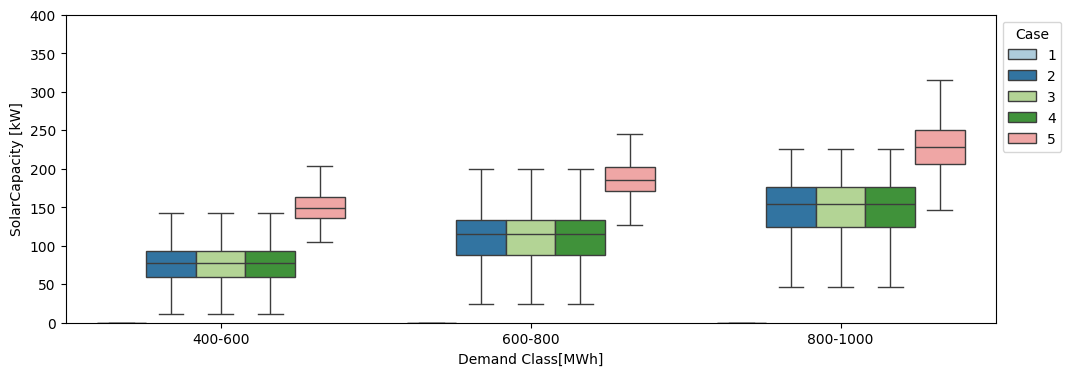

AnnualCost
Case                1         2         3         4         5
DemandClass                                                  
400          11848.85  11485.81  11618.89  10827.13  10584.19
600          16276.11  15745.70  15741.02  14950.34  14723.03
800          20458.46  19733.20  19688.16  18886.04  18669.86


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\482953051.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick)


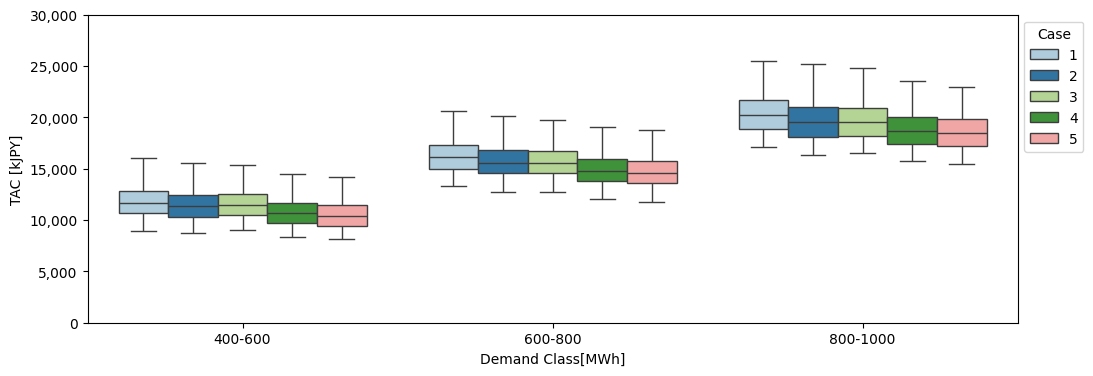

PBP
Case             2      4      5
DemandClass                     
400          14.77  10.72  12.36
600          14.79  10.92  12.37
800          14.69  11.28  12.55


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\482953051.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick)


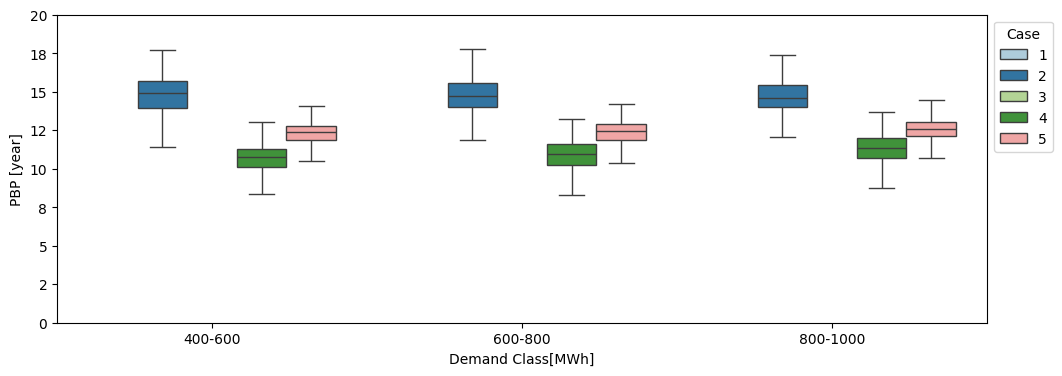

GHG_Total
Case              1       2       3       4       5
DemandClass                                        
400          234.72  195.12  170.79  168.36  129.74
600          319.53  261.76  237.44  233.89  194.40
800          400.04  322.53  298.20  293.86  253.45


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\482953051.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick)


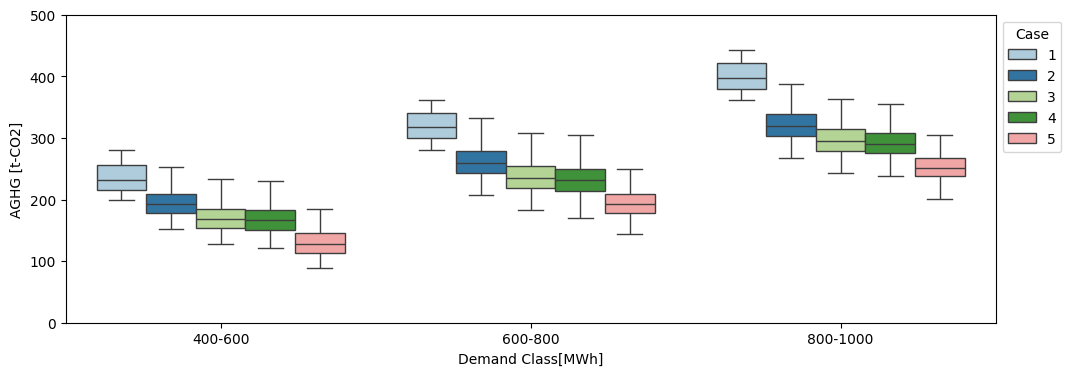

CPBP
Case           1     2     3     4     5
DemandClass                             
400          0.0  3.11  3.79  3.65  3.45
600          0.0  3.11  3.64  3.49  3.38
800          0.0  3.09  3.52  3.37  3.32


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\482953051.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick)


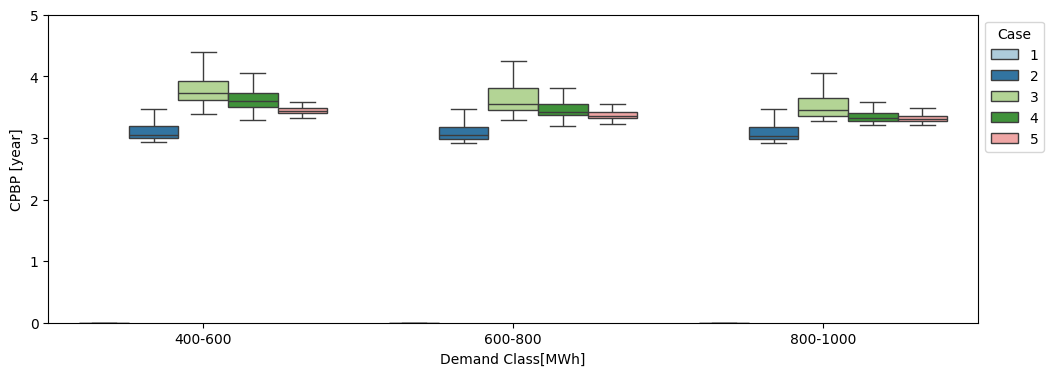

SSR[-]
Case           1     2     3     4     5
DemandClass                             
400          0.0  0.20  0.19  0.20  0.39
600          0.0  0.20  0.20  0.21  0.35
800          0.0  0.21  0.21  0.22  0.33


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\482953051.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick)


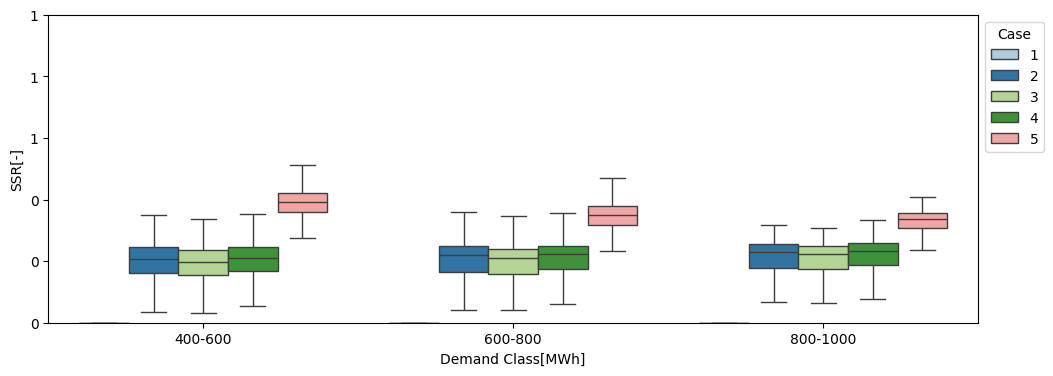

SCR[-]
Case           1     2     3    4     5
DemandClass                            
400          0.0  0.93  0.93  1.0  0.97
600          0.0  0.93  0.93  1.0  0.97
800          0.0  0.93  0.93  1.0  0.97


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\482953051.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick)


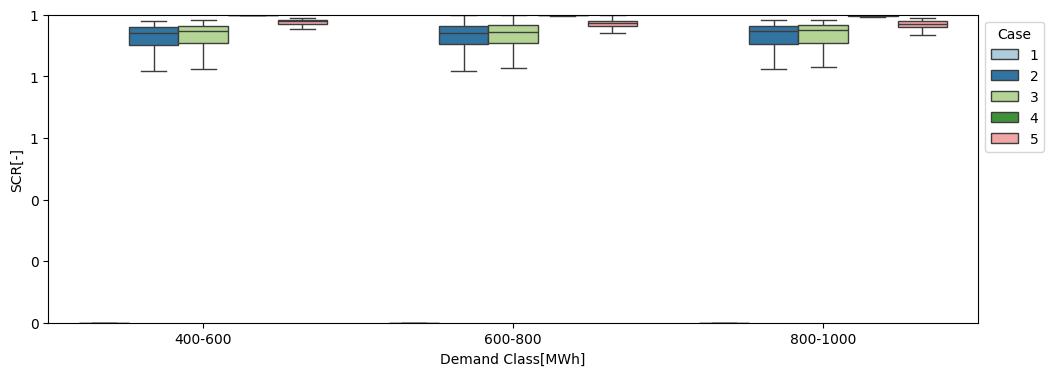

EnergyCost
Case               1        2        3        4       5
DemandClass                                            
400           781.56   626.24   669.77   660.24  508.77
600          1114.15   887.60   931.12   917.21  762.36
800          1429.86  1125.92  1169.40  1152.39  993.93


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\482953051.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick)


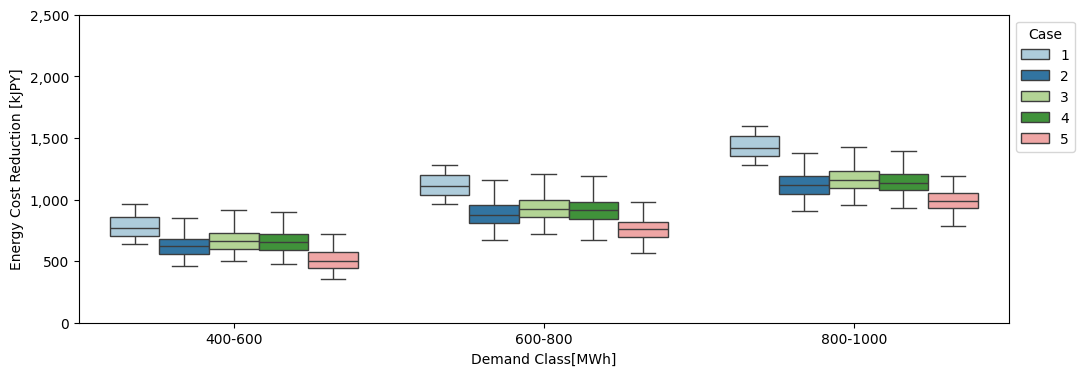

ContractCost
Case              1       2       3       4       5
DemandClass                                        
400          308.69  293.90  334.30  230.15  224.27
600          418.83  397.60  424.23  324.58  318.64
800          521.36  493.24  515.89  418.18  411.30


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\482953051.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick)


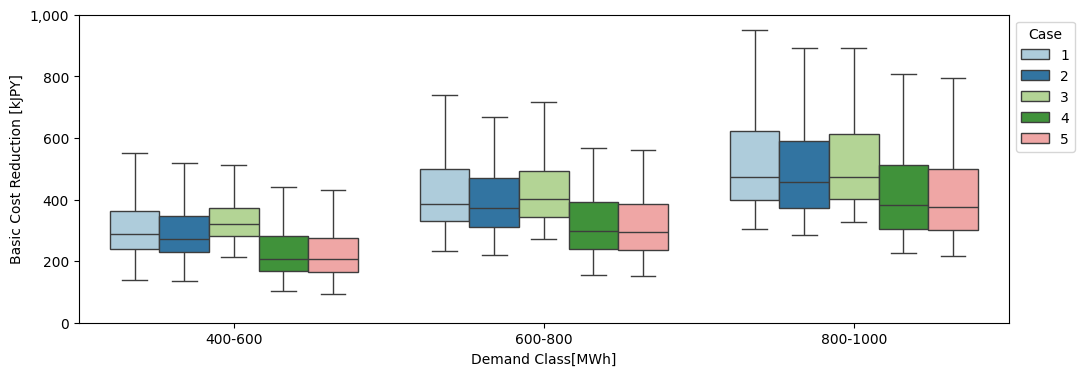

In [52]:
for metric in List_metric:
    print(metric)
    DF_group = DF_TEEA[["DemandClass","Case",metric]].reset_index(drop=True)
    if metric=="PBP":
        DF_group=DF_group[DF_group["Case"]!=1]
        DF_group=DF_group[DF_group["Case"]!=3]
    plt.figure(figsize=(12,4))
    ax = sns.boxplot(data=DF_group,x="DemandClass",y=metric,hue="Case",showfliers=False, palette="Paired",hue_order=hue_order)
    print(DF_group.groupby(["DemandClass","Case"]).mean()[metric].unstack().round(2))
    ax.set_xticklabels(xtick)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1),title="Case")
    ax.set_xlabel("Demand Class[MWh]")
    ax.set_ylabel(dict_graph_metric[metric]["unit"])
    ax.set_ylim(dict_graph_metric[metric]["ylim"])
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    plt.savefig("IMG/"+metric+"_box.png", bbox_inches='tight')
    plt.show()

SolarCapacity
Case       1       2       3       4       5
cluster                                     
A        0.0  113.56  113.56  113.56  179.14
B        0.0   93.32   93.32   93.32  180.35
C        0.0  103.98  103.98  103.98  185.40


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\207743345.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["A","B","C"])


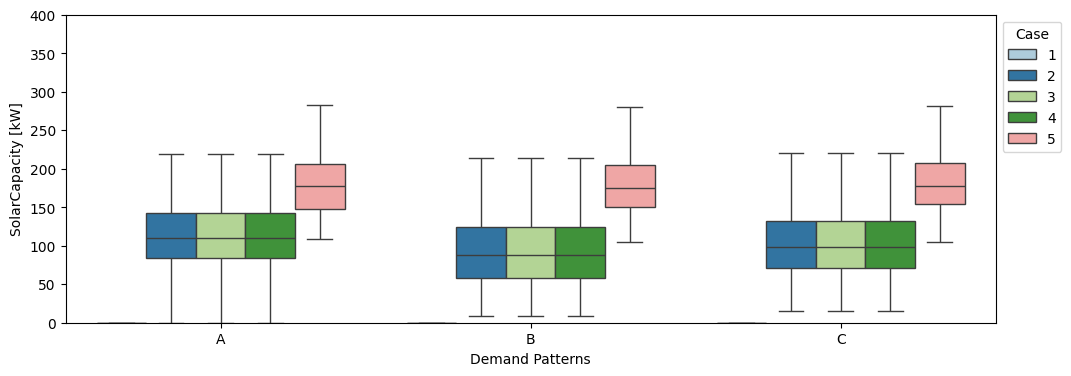

AnnualCost
Case            1         2         3         4         5
cluster                                                  
A        14599.15  14021.92  14163.95  13367.41  13170.52
B        15539.71  15115.60  15149.30  14318.32  14047.08
C        16658.77  16132.62  15962.75  15276.38  15062.60


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\207743345.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["A","B","C"])


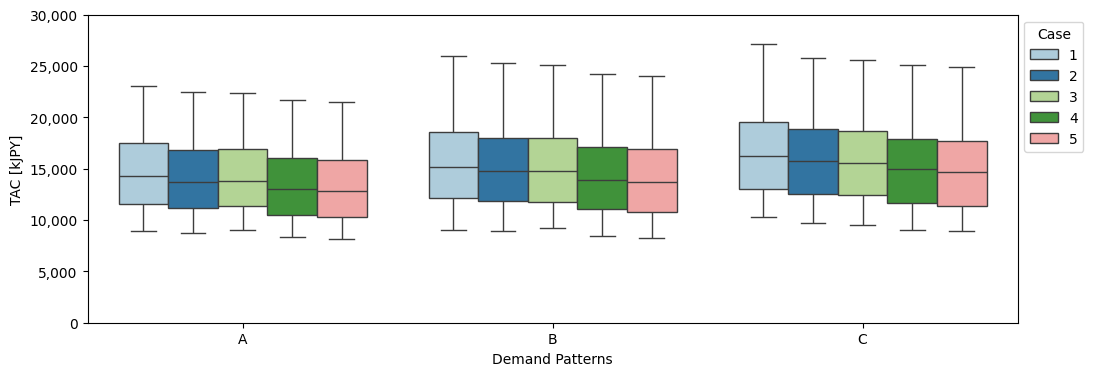

PBP
Case         2      4      5
cluster                     
A        14.41  11.35  12.50
B        15.13  10.65  12.39
C        14.66  10.50  12.21


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\207743345.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["A","B","C"])


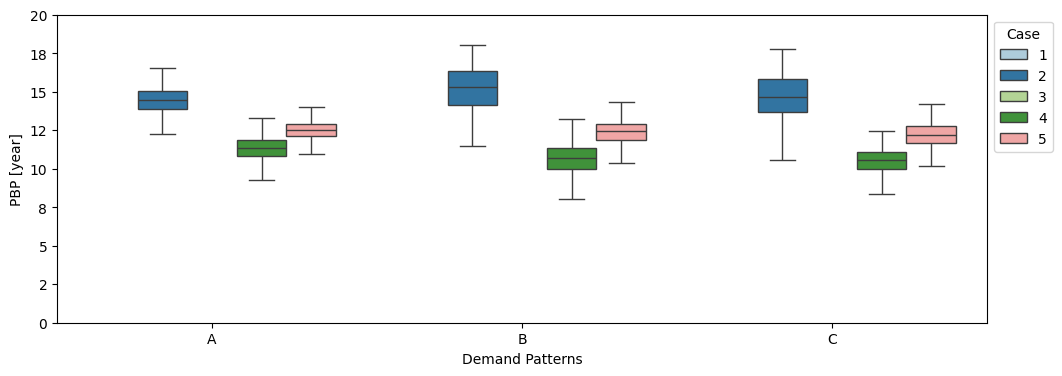

GHG_Total
Case          1       2       3       4       5
cluster                                        
A        302.30  240.64  216.28  214.30  180.80
B        299.97  251.58  227.34  223.58  178.82
C        303.60  251.12  226.63  221.51  181.76


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\207743345.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["A","B","C"])


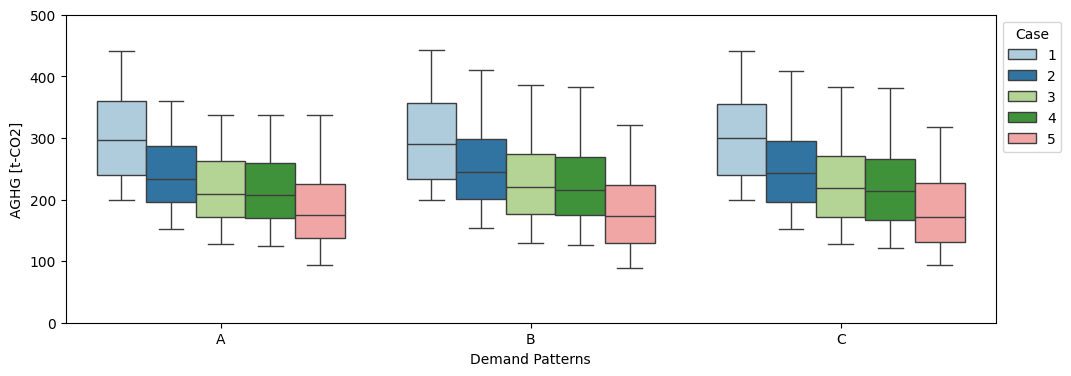

CPBP
Case       1     2     3     4     5
cluster                             
A        0.0  3.00  3.54  3.46  3.37
B        0.0  3.16  3.78  3.59  3.40
C        0.0  3.24  3.78  3.54  3.44


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\207743345.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["A","B","C"])


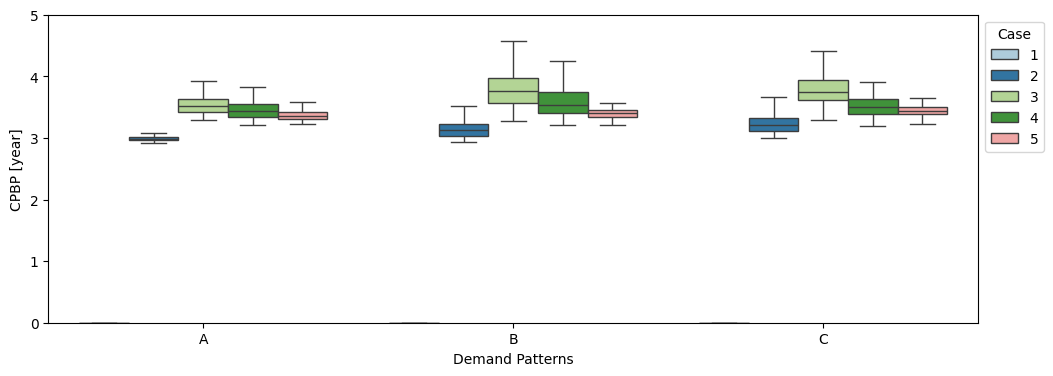

SSR[-]
Case       1     2     3     4     5
cluster                             
A        0.0  0.23  0.22  0.23  0.36
B        0.0  0.18  0.17  0.19  0.37
C        0.0  0.20  0.19  0.21  0.36


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\207743345.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["A","B","C"])


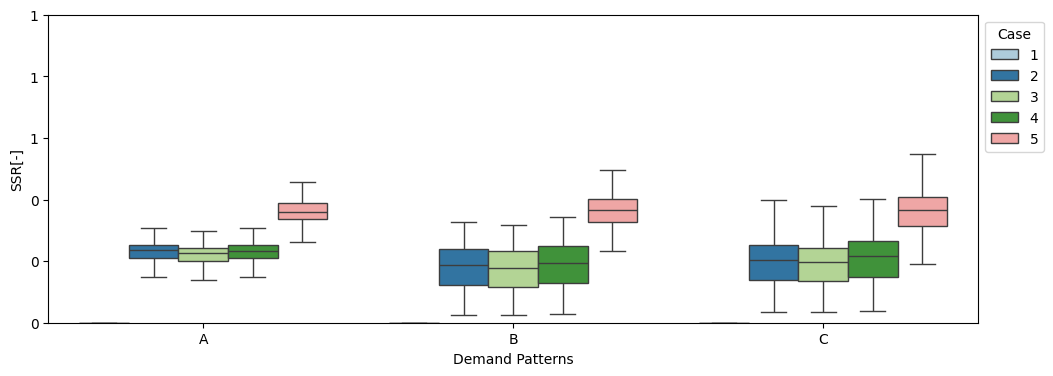

SCR[-]
Case       1     2     3     4     5
cluster                             
A        0.0  0.96  0.96  1.00  0.98
B        0.0  0.91  0.92  1.00  0.97
C        0.0  0.89  0.90  0.99  0.95


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\207743345.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["A","B","C"])


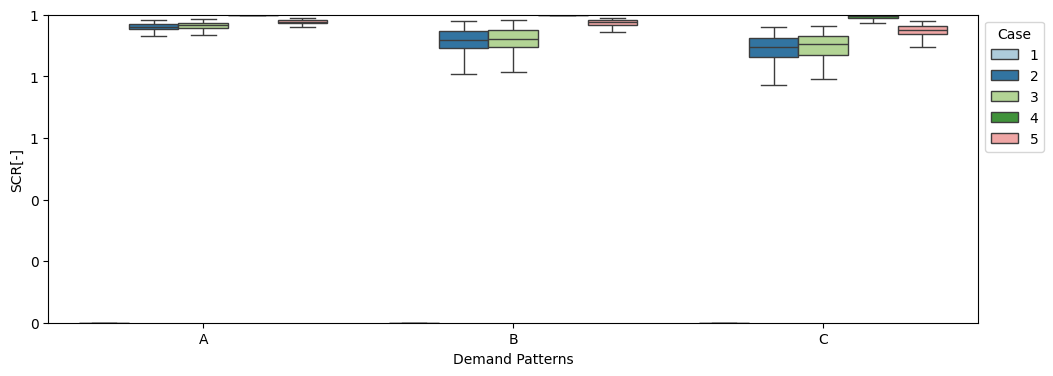

EnergyCost
Case           1       2       3       4       5
cluster                                         
A        1046.56  804.75  848.16  840.40  709.02
B        1037.42  847.68  891.55  876.77  701.25
C        1051.65  845.87  888.74  868.65  712.78


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\207743345.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["A","B","C"])


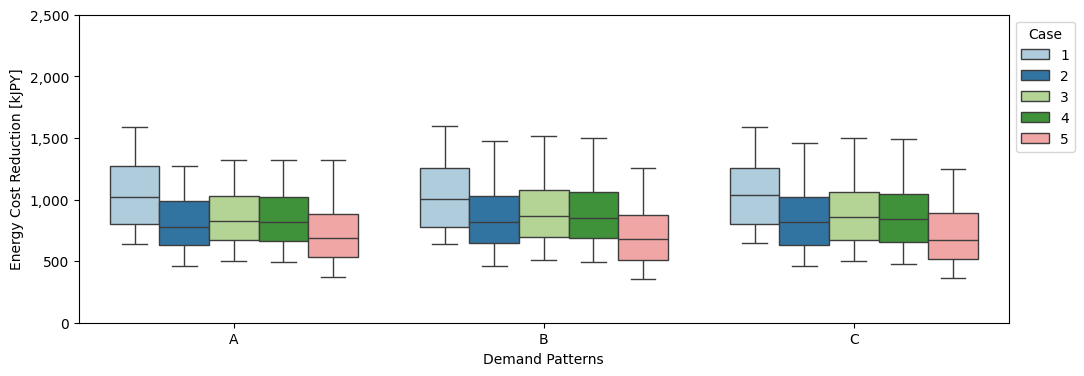

ContractCost
Case          1       2       3       4       5
cluster                                        
A        318.72  301.25  342.67  236.27  231.56
B        421.92  403.60  433.74  330.92  324.85
C        519.59  488.20  498.97  415.92  405.89


C:\Users\kiuch\AppData\Local\Temp\ipykernel_29444\207743345.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["A","B","C"])


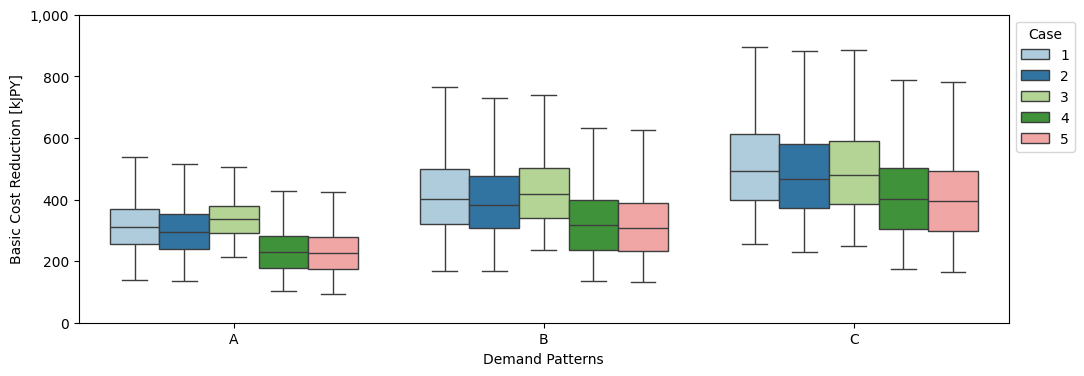

In [53]:
for metric in List_metric:
    print(metric)
    DF_group = DF_TEEA[["cluster","Case",metric]].reset_index(drop=True)
    if metric=="PBP":
        DF_group=DF_group[DF_group["Case"]!=1]
        DF_group=DF_group[DF_group["Case"]!=3]
    plt.figure(figsize=(12,4))
    
    ax = sns.boxplot(data=DF_group,x="cluster",y=metric,hue="Case",showfliers=False, palette="Paired",hue_order=hue_order)
    print(DF_group.groupby(["cluster","Case"]).mean()[metric].unstack().round(2))
    
    #ax.set_xticklabels(["A","B","C","D"])
    ax.set_xticklabels(["A","B","C"])
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1),title="Case")
    ax.set_xlabel("Demand Patterns")
    ax.set_ylabel(dict_graph_metric[metric]["unit"])
    ax.set_ylim(dict_graph_metric[metric]["ylim"])
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    plt.savefig("IMG/"+metric+"_cluster_box.png", bbox_inches='tight')
    plt.show()

In [54]:
dict_graph_metric["SSR[-]"]["ylim"]=(0,1)
dict_graph_metric["SCR[-]"]["ylim"]=(0,1)
dict_graph_metric["AnnualCost"]["ylim"]=(10000,30000)
dict_graph_metric["LCOE"]["ylim"]="LCOE[JPY/kWh]"
dict_graph_metric["PBP"]["ylim"]=(0,20)
dict_graph_metric["GHG_Comsumption"]["ylim"]="ComsumptionGHG[kg-CO2]"
dict_graph_metric["GHG_Total_Production"]["ylim"]="Total Production GHG[t-CO2]"
dict_graph_metric["GHG_Total"]["ylim"]=(0,500)
dict_graph_metric["CPBP"]["ylim"]=(0,5)
dict_graph_metric["SolarCapacity"]["ylim"]=(0,400)
dict_graph_metric["EnergyCost"]["ylim"]=(0,2500)
dict_graph_metric["ContractCost"]["ylim"]=(0,1000)

In [55]:
DF_group

,cluster,Case,ContractCost
0,A,1,293.016000
1,A,2,293.016000
2,A,3,333.610958
3,A,4,217.719235
4,A,5,215.170236
...,...,...,...
6675,A,1,426.388800
6676,A,2,401.973561
6677,A,3,403.965503
6678,A,4,341.349561


SolarCapacity
Case       1       2       3       4       5
cluster                                     
A        0.0  120.05  120.05  120.05  185.95
B        0.0  100.60  100.60  100.60  188.42
C        0.0  107.10  107.10  107.10  189.02


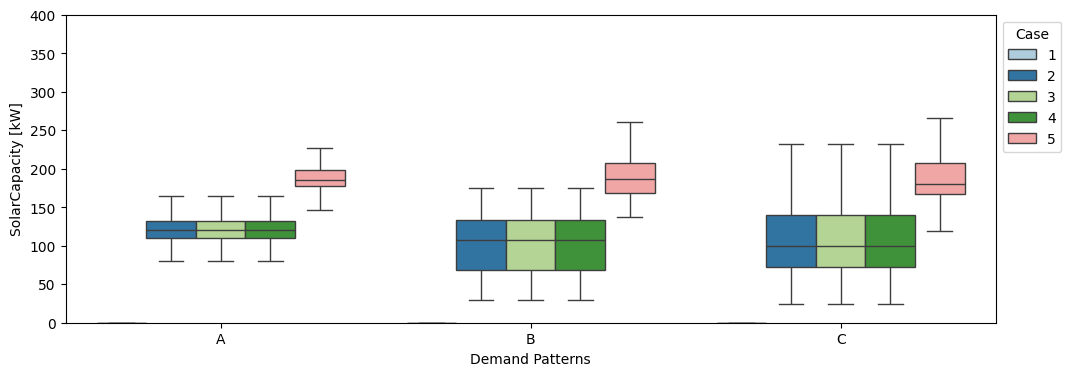

AnnualCost
Case            1         2         3         4         5
cluster                                                  
A        15474.40  14873.14  14924.15  14176.55  13981.80
B        16605.29  16142.98  16139.56  15277.00  15010.78
C        17427.76  16901.26  16756.12  16039.44  15829.34


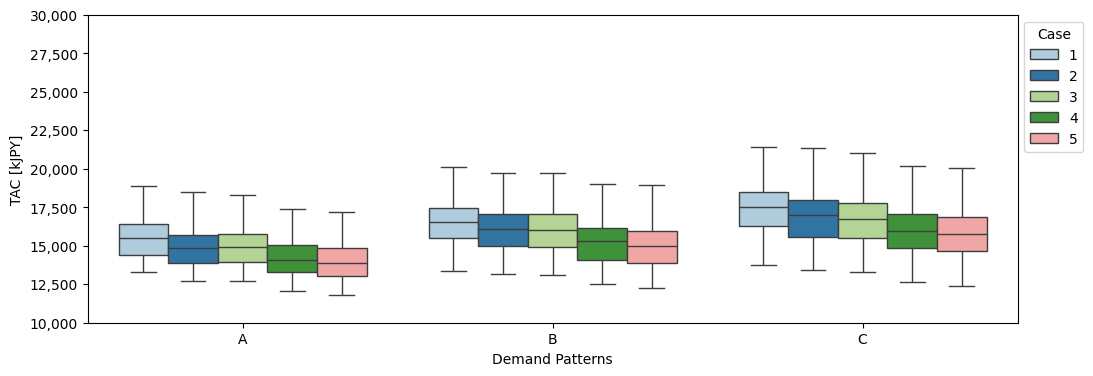

PBP
Case         2      4      5
cluster                     
A        14.45  11.37  12.46
B        15.10  10.61  12.30
C        14.83  10.60  12.29


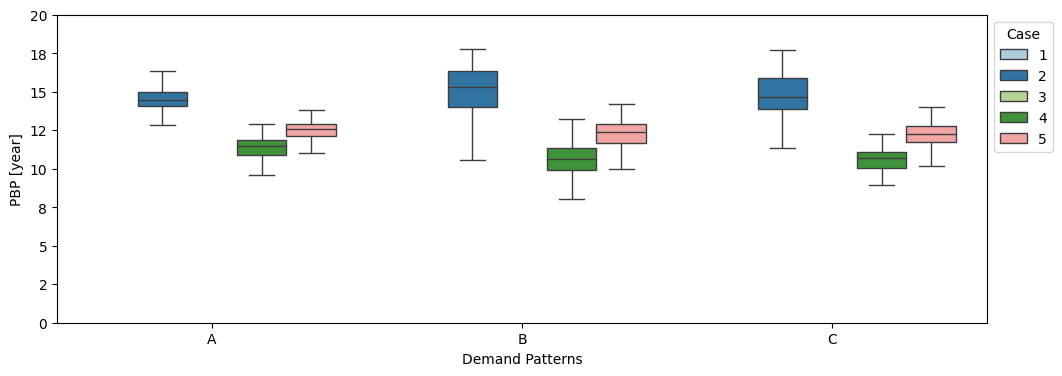

GHG_Total
Case          1       2       3       4       5
cluster                                        
A        319.25  254.08  229.73  227.59  194.01
B        319.45  267.67  243.44  239.05  194.04
C        320.45  265.89  241.40  236.47  196.27


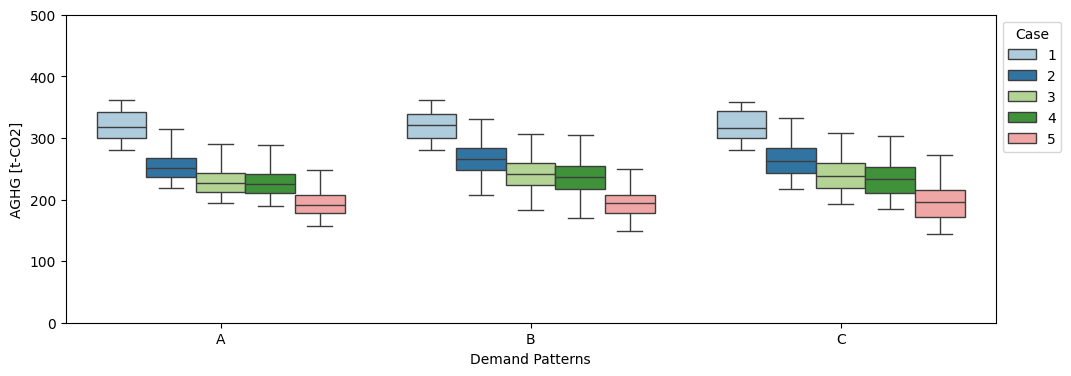

CPBP
Case       1     2     3     4     5
cluster                             
A        0.0  2.98  3.50  3.42  3.36
B        0.0  3.18  3.74  3.54  3.38
C        0.0  3.22  3.75  3.52  3.43


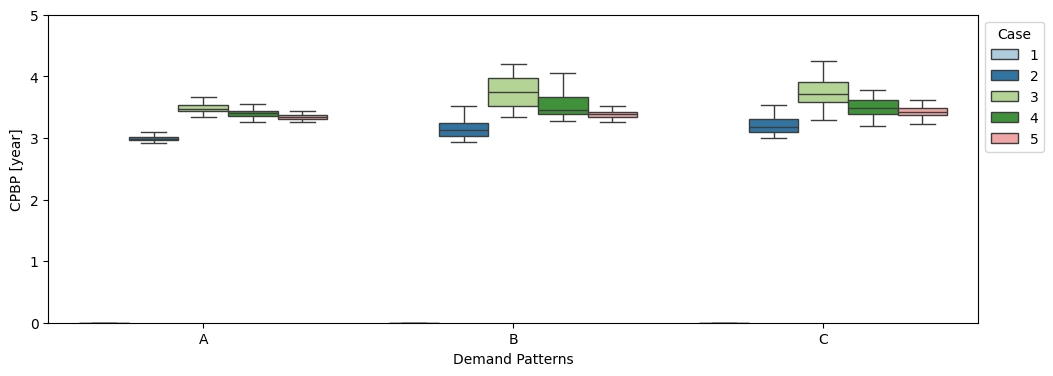

SSR[-]
Case       1     2     3     4     5
cluster                             
A        0.0  0.23  0.22  0.23  0.35
B        0.0  0.18  0.18  0.19  0.35
C        0.0  0.19  0.18  0.20  0.34


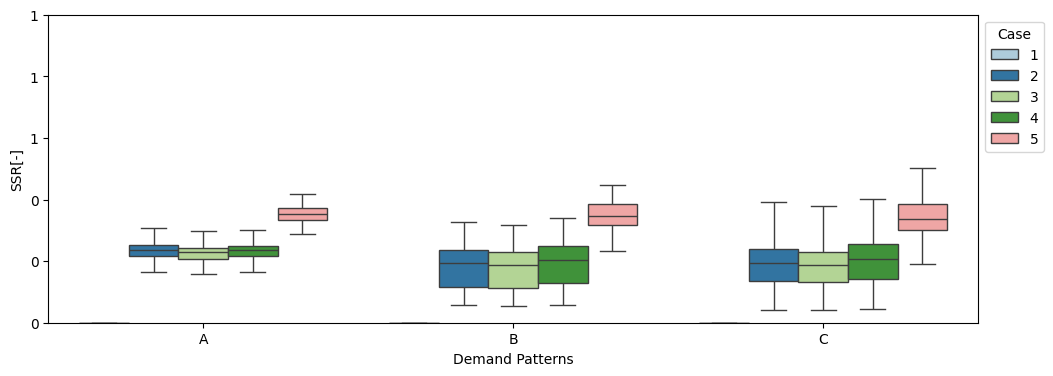

SCR[-]
Case       1     2     3     4     5
cluster                             
A        0.0  0.96  0.96  1.00  0.98
B        0.0  0.91  0.91  1.00  0.97
C        0.0  0.89  0.90  0.99  0.95


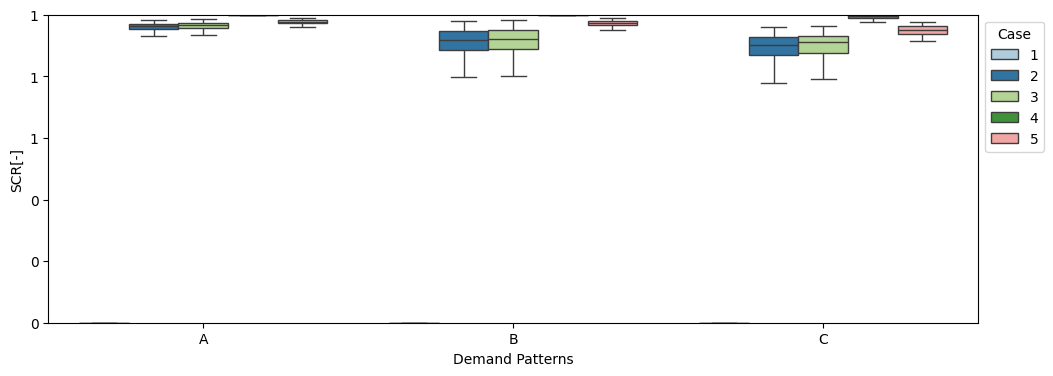

EnergyCost
Case           1       2       3       4       5
cluster                                         
A        1113.02  857.47  900.90  892.51  760.82
B        1113.84  910.77  954.65  937.46  760.95
C        1117.73  903.78  946.68  927.34  769.68


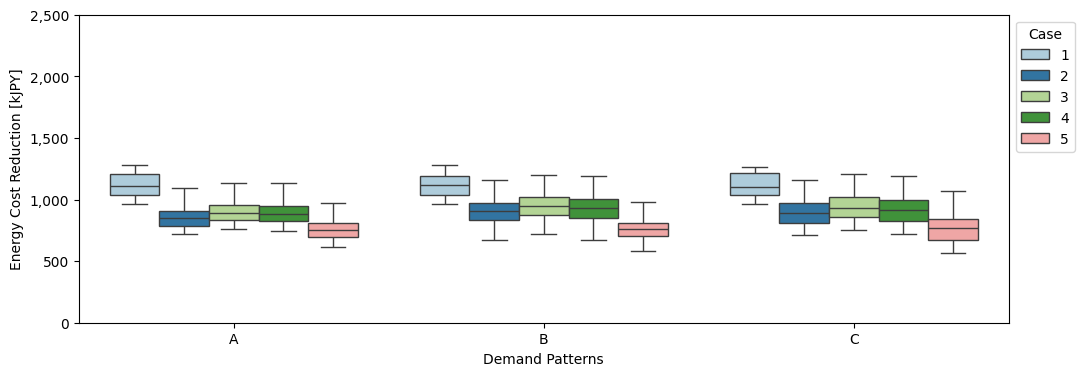

ContractCost
Case          1       2       3       4       5
cluster                                        
A        339.79  322.13  354.44  253.57  248.80
B        452.06  430.33  456.75  353.18  347.19
C        530.42  501.61  514.83  428.00  419.24


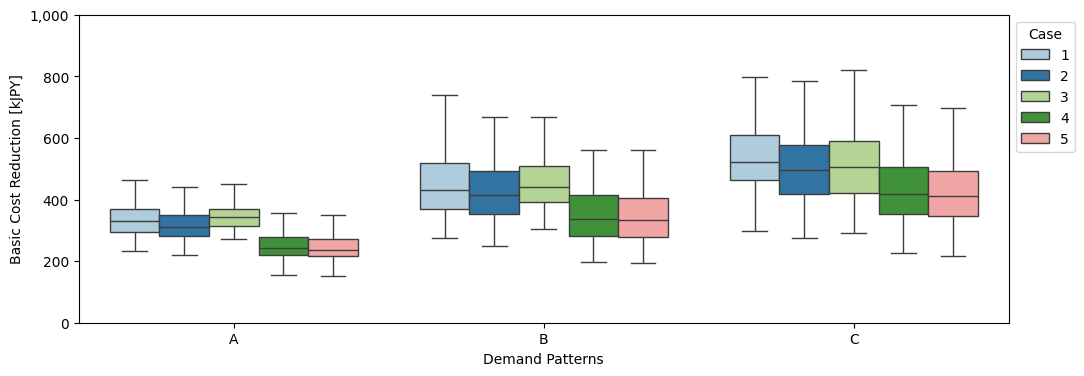

In [56]:
specifiedclass = 600
for metric in List_metric:
    print(metric)
    DF_group = DF_TEEA[DF_TEEA["DemandClass"]==specifiedclass][["cluster","Case",metric]].reset_index(drop=True)
    if metric=="PBP":
        DF_group=DF_group[DF_group["Case"]!=1]
        DF_group=DF_group[DF_group["Case"]!=3]
    plt.figure(figsize=(12,4))
    
    ax = sns.boxplot(data=DF_group,x="cluster",y=metric,hue="Case",showfliers=False, palette="Paired",hue_order=hue_order,order=hue_order_cluster)
    print(DF_group.groupby(["cluster","Case"]).mean()[metric].unstack().round(2))
    
    #ax.set_xticklabels(["A","B","C","D"])
    #ax.set_xticklabels(["A","B","C"])
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1),title="Case")
    ax.set_xlabel("Demand Patterns")
    ax.set_ylabel(dict_graph_metric[metric]["unit"])
    ax.set_ylim(dict_graph_metric[metric]["ylim"])
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    plt.savefig("IMG/"+metric+f"_cluster_{specifiedclass}_box.png", bbox_inches='tight')
    plt.show()

In [57]:
clusters = ["A", "B", "D"]
demandclasses = [600]

dfs = []

for c in clusters:
    for d in demandclasses:
        # 該当データ
        tmp = DF_TEEA[
            (DF_TEEA["cluster"] == c) &
            (DF_TEEA["DemandClass"] == d)
        ]
        # nameを3つランダム抽出
        names = (
            tmp["name"]
            .drop_duplicates()
            .sample(3, random_state=0)
        )

        # 抽出したnameに対応する全Caseを取得
        tmp_sel = tmp[tmp["name"].isin(names)].round(2)
        print(c,d)
        print(tmp_sel[["Case"]+List_metric[:-2]])


A 600
      Case  SolarCapacity  AnnualCost    PBP  GHG_Total  CPBP  SSR[-]  SCR[-]
606      1           0.00    13861.24   0.00     280.76  0.00    0.00    0.00
607      2          98.46    13337.61  14.11     227.96  3.03    0.22    0.95
608      3          98.46    13116.66  11.98     203.75  3.60    0.21    0.95
610      4          98.46    12589.85  10.71     201.23  3.48    0.22    1.00
611      5         171.43    12365.19  12.12     164.35  3.40    0.36    0.97
4578     1           0.00    15054.72   0.00     319.95  0.00    0.00    0.00
4579     2         107.95    14631.96  15.30     260.31  2.94    0.21    0.97
4580     3         107.95    14683.86  14.43     235.89  3.48    0.20    0.98
4582     4         107.95    13937.35  11.57     235.45  3.46    0.21    1.00
4583     5         169.41    13760.51  12.65     203.13  3.36    0.32    0.98
5496     1           0.00    15660.54   0.00     328.19  0.00    0.00    0.00
5497     2         130.30    15109.10  15.02     257.68  3

ValueError: a must be greater than 0 unless no samples are taken

AnnualCost & PBP


C:\Users\kiuch\AppData\Local\Temp\ipykernel_7444\3972121548.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtick)


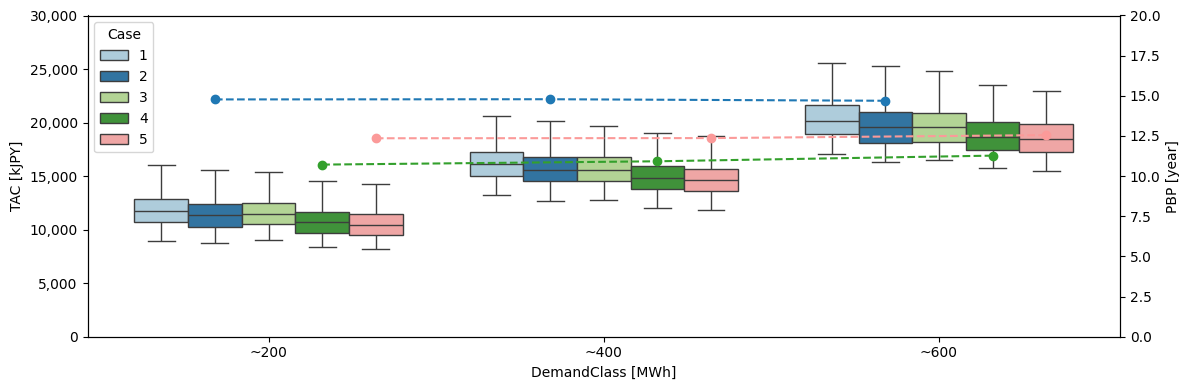

GHG_Total & CPBP


C:\Users\kiuch\AppData\Local\Temp\ipykernel_7444\3972121548.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtick)


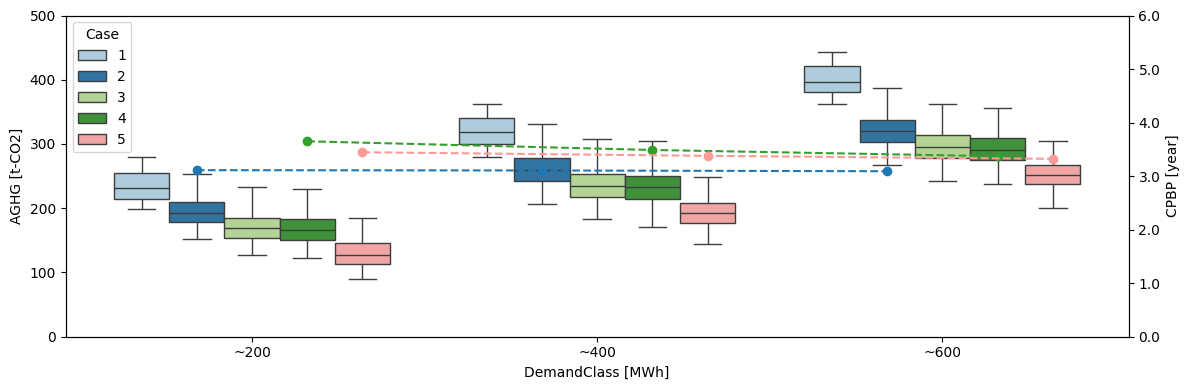

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import numpy as np

pair_metrics = [("AnnualCost", "PBP"), ("GHG_Total", "CPBP")]

for box_metric, dot_metric in pair_metrics:
    print(f"{box_metric} & {dot_metric}")

    # データ準備
    DF_plot = DF_TEEA[["DemandClass", "Case", box_metric, dot_metric]].copy()

    
    # カテゴリの順序を明示（横軸がズレないように）
    demand_order = sorted(DF_plot["DemandClass"].unique())
    case_order = hue_order

    # 描画の準備
    plt.figure(figsize=(12, 4))
    ax1 = sns.boxplot(
        data=DF_plot, x="DemandClass", y=box_metric, hue="Case",
        palette="Paired", hue_order=case_order, showfliers=False, order=demand_order
    )

    # 左Y軸の設定
    ax1.set_ylabel(dict_graph_metric[box_metric]["unit"])
    ax1.set_ylim(dict_graph_metric[box_metric]["ylim"])
    ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    ax1.set_xlabel("DemandClass [MWh]")
    ax1.set_xticklabels(xtick)
    #ax1.set_title(f"{box_metric} (box) + {dot_metric} (mean dot)")

    # PBP や CPBP に対して Case 1, 3 を除外（必要なら）
    if dot_metric in ["PBP", "CPBP"]:
        DF_plot = DF_plot[~DF_plot["Case"].isin([1, 3])].reset_index(drop=True)


     

    # 右Y軸（平均ドット）を追加
    ax2 = ax1.twinx()

    # 平均値を計算
    df_mean = DF_plot.groupby(["DemandClass", "Case"], as_index=False)[dot_metric].mean()

    # 各カテゴリの x 軸位置を取得
    demand_class_idx = {d: i for i, d in enumerate(demand_order)}  # category name → index
    total_cases = len(case_order)
    width = 0.8 / total_cases  # spacing within box groups

    # ドット描画
    palette = sns.color_palette("Paired")
    for ci, case in enumerate(case_order):
        sub = df_mean[df_mean["Case"] == case]
        if sub.empty:
            continue
        x_vals = [demand_class_idx[d] - 0.4 + width/2 + ci*width for d in sub["DemandClass"]]
        ax2.plot(x_vals, sub[dot_metric], 'o--', label=None, color=palette[ci])

    # 右Y軸の設定
    ax2.set_ylabel(dict_graph_metric[dot_metric]["unit"])
    ax2.set_ylim(dict_graph_metric[dot_metric]["ylim"])
    ax2.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.1f}'))

    
    # 保存と表示
    plt.tight_layout()
    plt.savefig(f"IMG/{box_metric}_{dot_metric}_dual_axis_boxdot_fixed.png", bbox_inches='tight')
    plt.show()


In [ ]:
# for metric in List_metric:
#     for reference in dictScinario.keys():
#         for scinario in dictScinario.keys():
#             dfref=DF_TEEA[DF_TEEA["Scinario"]==reference].reset_index()
#             dfscio=DF_TEEA[DF_TEEA["Scinario"]==scinario].reset_index()
#             if (dfscio["Case"].iloc[0] - dfref["Case"].iloc[0])>1:continue
#             if (dfscio["Case"].iloc[0]<=dfref["Case"].iloc[0]):continue
#             print(metric)
#             print("scio",dfscio["Case"].iloc[0])
#             print("ref",dfref["Case"].iloc[0])
            
#             df = dfref[["name","Demand","DemandClass","cluster"]]
#             if metric=="SolarCapacity":
#                 df.loc[:,metric] = dfscio.loc[:,metric]-dfref.loc[:,metric]
#             else:    
#                 df.loc[:,metric] = dfref.loc[:,metric]-dfscio.loc[:,metric]
#             df = df.dropna()
#             ax1 = sns.boxplot(data=df,x="DemandClass",y=metric,hue="cluster",hue_order=hue_order_cluster)
#             ax1.set_ylabel(dict_graph_metric[metric]["unit"])  
#             ax1.set_xlabel("Annual Demand[MWh]")  
#             ax1.set_xticklabels(xtick)
#             ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
#             plt.savefig("IMG/"+str(reference)+"-"+str(scinario)+str(metric)+"_box.png", bbox_inches='tight')
#             plt.show()
#             ax2=sns.scatterplot(data=df,x="Demand",y=metric,hue="cluster",hue_order=hue_order_cluster)
#             ax2.set_ylabel(dict_graph_metric[metric]["unit"])  
#             ax2.set_xlabel("Annual Demand[MWh]")  
#             ax2.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
#             plt.savefig("IMG/"+str(reference)+"-"+str(scinario)+str(metric)+"_scatter.png", bbox_inches='tight')
#             plt.show()

In [ ]:
DF_TEEA

,name,Num_EV,TripEnergy,Demand,RES,SolarCapacity,BESS_BatteryCapacity,BuyPowerEnergy,ContractPower,Cost,...,CPBP,Cost_trvl,Prod_cost,OM_cost,Annual_Prod_cost,ElectricityCost,TotalCost,AnnualCost,GHG_Additional_Production,Case
0,B11000005,0,0.00000,658.617,0.000000,0.000000,0,658617.000000,145.000000,1346.803200,...,0.000000,94.630057,0.000000,0.000000,0.000000,1346.803200,1441.433257,14414.332568,NaN,1
1,B11000005,0,0.00000,658.617,144850.434329,104.347826,0,520105.655756,145.000000,1125.185049,...,3.003463,94.630057,2660.869557,52.173913,185.217391,1125.185049,3880.684663,14050.324968,169733.564425,2
2,B11000005,15,27829.91638,658.617,144850.434329,104.347826,0,548135.769598,165.088558,1210.628189,...,3.558623,0.000000,2885.869557,53.673913,209.217391,1210.628189,4096.497746,14198.455796,286472.321647,3
4,B11000005,15,27829.91638,658.617,144850.434329,104.347826,0,543163.819147,107.739130,1086.781345,...,3.471153,0.000000,3155.869557,61.173913,243.717391,1086.781345,4242.650902,13304.987362,286472.321647,4
5,B11000005,15,27829.91638,658.617,238527.170604,171.830977,0,455459.474641,106.477749,943.905395,...,3.349099,0.000000,4876.689911,94.915488,363.499984,943.905395,5820.595306,13074.053791,396241.314921,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8010,B11006531,0,0.00000,979.557,0.000000,0.000000,0,979557.000000,211.000000,1993.680000,...,0.000000,94.630057,0.000000,0.000000,0.000000,1993.680000,2088.310057,20883.100568,NaN,1
8011,B11006531,0,0.00000,979.557,280070.999737,201.639344,0,711113.623606,198.918033,1539.755358,...,2.994655,94.630057,5141.803274,100.819672,357.909836,1539.755358,6776.188689,19922.952510,327989.245091,2
8012,B11006531,15,27067.50693,979.557,280070.999737,201.639344,0,737799.322829,199.903753,1584.444420,...,3.317339,0.000000,5366.803274,102.319672,381.909836,1584.444420,6951.247694,19663.542555,444728.002312,3
8014,B11006531,15,27067.50693,979.557,280070.999737,201.639344,0,728142.571982,168.918033,1506.377676,...,3.222629,0.000000,5636.803274,109.819672,416.409836,1506.377676,7143.180950,19227.875116,444728.002312,4


In [ ]:
names = DF_TEEA["name"].unique()
u_clusters = DF_TEEA["cluster"].unique()
print(len(names),u_clusters)

1336 ['D' 'A' 'B']


In [ ]:
DF_TEEA

,name,Num_EV,TripEnergy,Demand,RES,SolarCapacity,BESS_BatteryCapacity,BuyPowerEnergy,ContractPower,Cost,...,CPBP,Cost_trvl,Prod_cost,OM_cost,Annual_Prod_cost,ElectricityCost,TotalCost,AnnualCost,GHG_Additional_Production,Case
0,B11000005,0,0.00000,658.617,0.000000,0.000000,0,658617.000000,145.000000,1346.803200,...,0.000000,94.630057,0.000000,0.000000,0.000000,1346.803200,1441.433257,14414.332568,NaN,1
1,B11000005,0,0.00000,658.617,144850.434329,104.347826,0,520105.655756,145.000000,1125.185049,...,3.003463,94.630057,2660.869557,52.173913,185.217391,1125.185049,3880.684663,14050.324968,169733.564425,2
2,B11000005,15,27829.91638,658.617,144850.434329,104.347826,0,548135.769598,165.088558,1210.628189,...,3.558623,0.000000,2885.869557,53.673913,209.217391,1210.628189,4096.497746,14198.455796,286472.321647,3
4,B11000005,15,27829.91638,658.617,144850.434329,104.347826,0,543163.819147,107.739130,1086.781345,...,3.471153,0.000000,3155.869557,61.173913,243.717391,1086.781345,4242.650902,13304.987362,286472.321647,4
5,B11000005,15,27829.91638,658.617,238527.170604,171.830977,0,455459.474641,106.477749,943.905395,...,3.349099,0.000000,4876.689911,94.915488,363.499984,943.905395,5820.595306,13074.053791,396241.314921,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8010,B11006531,0,0.00000,979.557,0.000000,0.000000,0,979557.000000,211.000000,1993.680000,...,0.000000,94.630057,0.000000,0.000000,0.000000,1993.680000,2088.310057,20883.100568,NaN,1
8011,B11006531,0,0.00000,979.557,280070.999737,201.639344,0,711113.623606,198.918033,1539.755358,...,2.994655,94.630057,5141.803274,100.819672,357.909836,1539.755358,6776.188689,19922.952510,327989.245091,2
8012,B11006531,15,27067.50693,979.557,280070.999737,201.639344,0,737799.322829,199.903753,1584.444420,...,3.317339,0.000000,5366.803274,102.319672,381.909836,1584.444420,6951.247694,19663.542555,444728.002312,3
8014,B11006531,15,27067.50693,979.557,280070.999737,201.639344,0,728142.571982,168.918033,1506.377676,...,3.222629,0.000000,5636.803274,109.819672,416.409836,1506.377676,7143.180950,19227.875116,444728.002312,4


In [ ]:
sc6 = DF_TEEA[DF_TEEA["Scinario"]==6].reset_index()
sc5 = DF_TEEA[DF_TEEA["Scinario"]==5].reset_index()
sc4 = DF_TEEA[DF_TEEA["Scinario"]==4].reset_index()
sc3 = DF_TEEA[DF_TEEA["Scinario"]==3].reset_index()
sc2 = DF_TEEA[DF_TEEA["Scinario"]==2].reset_index()
sc1 = DF_TEEA[DF_TEEA["Scinario"]==1].reset_index()
print(len(sc6),len(sc5),len(sc4),len(sc3),len(sc2),len(sc1))

1336 1336 0 1336 1336 1336


In [ ]:
#Demand A
DF_TEEA[DF_TEEA["name"]=="B11005006"][["DemandClass","cluster","AnnualCost","PBP","GHG_Total","CPBP"]]

,DemandClass,cluster,AnnualCost,PBP,GHG_Total,CPBP
5988,600,B,18941.324568,0.000000,356.196184,0.000000
5989,600,B,17359.470094,13.026281,230.824500,3.006749
5990,600,B,17098.336792,12.068253,206.428483,3.296438
5992,600,B,16261.867879,10.820916,201.358856,3.188507
5993,600,B,16063.848602,11.691066,165.773511,3.226684


In [ ]:
#Demand B
DF_TEEA[DF_TEEA["name"]=="B11002460"][["DemandClass","cluster","AnnualCost","PBP","GHG_Total","CPBP"]]

,DemandClass,cluster,AnnualCost,PBP,GHG_Total,CPBP
2898,600,A,16007.580568,0.000000,288.599968,0.000000
2899,600,A,15836.822380,16.459598,259.592669,3.491525
2900,600,A,15583.987593,12.062304,235.315911,4.091626
2902,600,A,14593.831651,8.739575,229.297542,3.676383
2903,600,A,14125.608695,11.606185,166.185944,3.505501


In [ ]:
Energy_PV = (sc1["BuyPowerEnergy"]-sc2["BuyPowerEnergy"])/sc1["BuyPowerEnergy"]
Energy_V2B = (sc3["BuyPowerEnergy"]-sc5["BuyPowerEnergy"])/sc1["BuyPowerEnergy"]
Energy_V2BPV = (sc5["BuyPowerEnergy"]-sc6["BuyPowerEnergy"])/sc1["BuyPowerEnergy"]

cluster = sc1["cluster"]
demandclass = sc1["DemandClass"]
#condition = (cluster != "A")& (cluster != "D")&(demandclass>200)
condition = (demandclass>100)
DemandA = sc1["name"]=="B11005006"
DemandB = sc1["name"]=="B11002460"
print(sum(condition))

1336


c:\Users\kiuch\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\text.py:753: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(self._x))
c:\Users\kiuch\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\text.py:754: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(self._y))
c:\Users\kiuch\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\text.py:894: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
c:\Users\kiuch\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\text.py:895: FutureWarning: Calling float on a single element Se

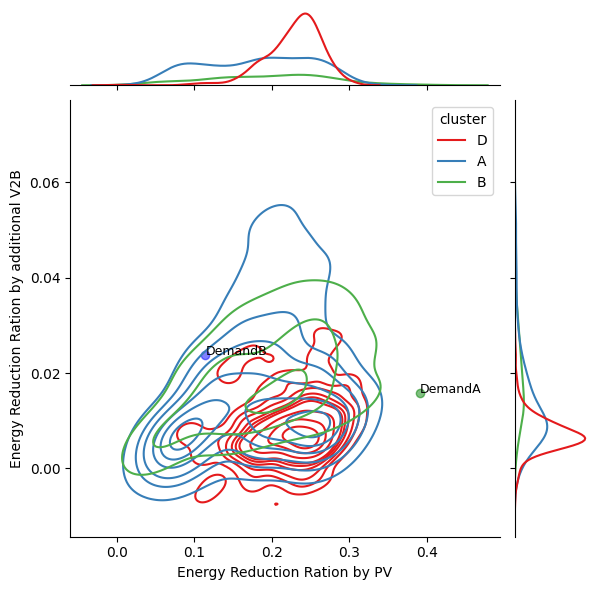

In [ ]:
g = sns.jointplot(x=Energy_PV[condition], y=Energy_V2B[condition], hue=cluster[condition], kind="kde")
g.set_axis_labels("Energy Reduction Ration by PV", "Energy Reduction Ration by additional V2B")  # ここでラベルを変更
ax = g.ax_joint  # jointplotの軸を取得
ax.scatter(Energy_PV[DemandA], Energy_V2B[DemandA], color='green', label='Demand A', alpha=0.5)
ax.scatter(Energy_PV[DemandB], Energy_V2B[DemandB], color='blue', label='Demand B', alpha=0.5)
ax.text(Energy_PV[DemandA], Energy_V2B[DemandA], 'DemandA', fontsize=9, color='black')
ax.text(Energy_PV[DemandB], Energy_V2B[DemandB], 'DemandB', fontsize=9, color='black')
plt.show()

c:\Users\kiuch\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\text.py:753: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(self._x))
c:\Users\kiuch\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\text.py:754: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(self._y))
c:\Users\kiuch\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\text.py:894: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
c:\Users\kiuch\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\text.py:895: FutureWarning: Calling float on a single element Se

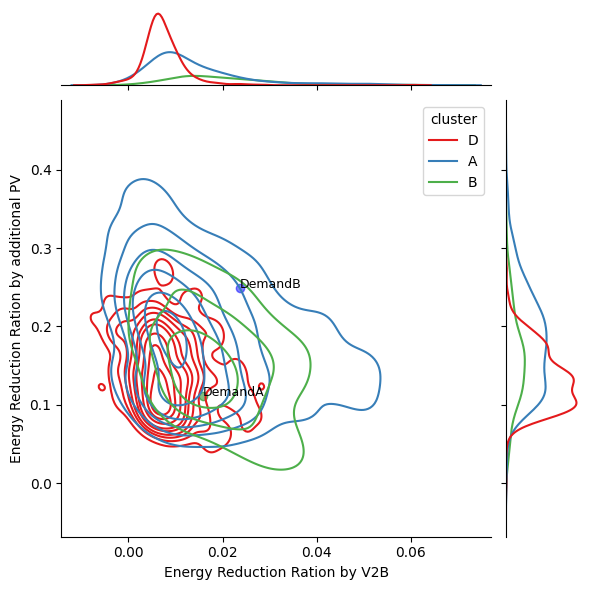

In [ ]:
g = sns.jointplot(x=Energy_V2B[condition], y=Energy_V2BPV[condition], hue=cluster[condition], kind="kde")
g.set_axis_labels("Energy Reduction Ration by V2B", "Energy Reduction Ration by additional PV")  # ここでラベルを変更
ax = g.ax_joint  # jointplotの軸を取得
ax.scatter(Energy_V2B[DemandA], Energy_V2BPV[DemandA], color='green', label='Demand A', alpha=0.5)
ax.scatter(Energy_V2B[DemandB], Energy_V2BPV[DemandB], color='blue', label='Demand B', alpha=0.5)
ax.text(Energy_V2B[DemandA], Energy_V2BPV[DemandA], 'DemandA', fontsize=9, color='black')
ax.text(Energy_V2B[DemandB], Energy_V2BPV[DemandB], 'DemandB', fontsize=9, color='black')

plt.show()

c:\Users\kiuch\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\text.py:753: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(self._x))
c:\Users\kiuch\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\text.py:754: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(self._y))
c:\Users\kiuch\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\text.py:894: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
c:\Users\kiuch\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\text.py:895: FutureWarning: Calling float on a single element Se

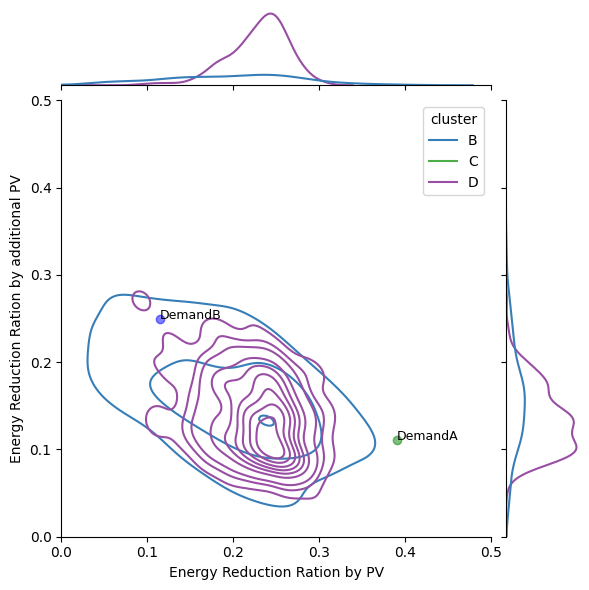

In [ ]:
hue_order = ["B", "C", "D"]  # hue_orderを指定して順番を固定

g = sns.jointplot(x=Energy_PV[condition], y=Energy_V2BPV[condition], hue=cluster[condition], kind="kde", hue_order=hue_order, palette=cluster_color_map)
g.set_axis_labels("Energy Reduction Ration by PV", "Energy Reduction Ration by additional PV")  # ここでラベルを変更
ax = g.ax_joint  # jointplotの軸を取得
ax.scatter(Energy_PV[DemandA], Energy_V2BPV[DemandA], color='green', label='Demand A', alpha=0.5)
ax.scatter(Energy_PV[DemandB], Energy_V2BPV[DemandB], color='blue', label='Demand B', alpha=0.5)
ax.text(Energy_PV[DemandA], Energy_V2BPV[DemandA], 'DemandA', fontsize=9, color='black')
ax.text(Energy_PV[DemandB], Energy_V2BPV[DemandB], 'DemandB', fontsize=9, color='black')
ax.set_xlim(0, 0.5)
ax.set_ylim(0, 0.5)


plt.show()

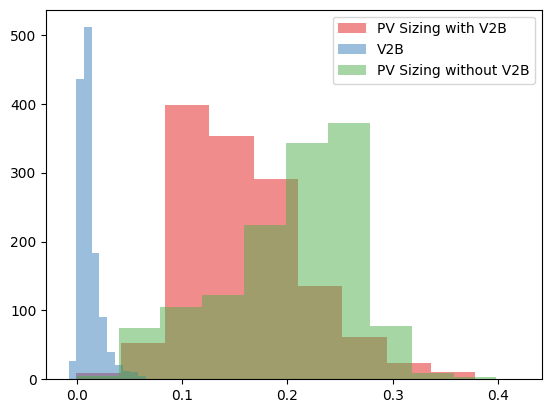

In [ ]:
plt.hist(Energy_V2BPV[condition],alpha=0.5,label="PV Sizing with V2B")
plt.hist(Energy_V2B[condition],alpha=0.5,label="V2B")
plt.hist(Energy_PV[condition],alpha=0.5,label="PV Sizing without V2B")
plt.legend()